# Análisis Exploratorio de Datos (EDA) - Sarampión y Vacunación en México 2010-2023

Este notebook analiza la relación entre las dosis de vacunas SRP (Sarampión, Rubéola y Parotiditis) aplicadas y los casos de sarampión reportados en México desde 2010 hasta 2023.

## 1. Importar Librerías

In [20]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [21]:
base_path = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
processed_data_path = f'{base_path}/data/processed/'
print(f"Ruta de datos procesados: {processed_data_path}")

# Definir la ruta al archivo CSV del dataset
DATASET_FILE = f'{processed_data_path}dataset_sarampion_vacunas_2010-2023.csv'

Ruta de datos procesados: /home/gerardo/maestria/proyecto_terminal/data/processed/


## 2. Cargar el Dataset de Sarampión y Vacunas

Cargamos el dataset consolidado que contiene información mensual de dosis de vacunas aplicadas y casos de sarampión reportados.

In [22]:
# Verificar que el archivo existe
if os.path.exists(DATASET_FILE):
    print(f"✓ Archivo encontrado: {os.path.basename(DATASET_FILE)}")
    print(f"  Tamaño: {os.path.getsize(DATASET_FILE) / 1024:.2f} KB")
else:
    print(f"✗ Error: No se encontró el archivo en la ruta especificada")
    print(f"  Ruta buscada: {DATASET_FILE}")

✓ Archivo encontrado: dataset_sarampion_vacunas_2010-2023.csv
  Tamaño: 2.87 KB


In [23]:
# Cargar el dataset
try:
    df = pd.read_csv(DATASET_FILE, encoding='utf-8')
    print(f"✓ Dataset cargado exitosamente")
    print(f"  Total de registros: {len(df):,}")
    print(f"  Total de columnas: {len(df.columns)}")
    print(f"{'='*60}")
except Exception as e:
    print(f"✗ Error al cargar el archivo: {str(e)}")

✓ Dataset cargado exitosamente
  Total de registros: 168
  Total de columnas: 4


In [24]:
# Verificar las columnas del dataset
print(f"\n{'='*60}")
print("COLUMNAS DEL DATASET:")
print(f"{'='*60}")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. '{col}'")
print(f"{'='*60}")


COLUMNAS DEL DATASET:
1. 'mes'
2. 'anio'
3. 'total_dosis'
4. 'casos_sarampion'


## 3. Exploración Inicial del Dataset

In [25]:
# Información general del dataset
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*60)
df.info()
print("\n" + "="*60)

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   mes              168 non-null    int64
 1   anio             168 non-null    int64
 2   total_dosis      168 non-null    int64
 3   casos_sarampion  168 non-null    int64
dtypes: int64(4)
memory usage: 5.4 KB



In [26]:
# Primeras y últimas filas del dataset
print("PRIMERAS 10 FILAS DEL DATASET")
print("="*60)
display(df.head(10))

print("\nÚLTIMAS 10 FILAS DEL DATASET")
print("="*60)
display(df.tail(10))

PRIMERAS 10 FILAS DEL DATASET


,mes,anio,total_dosis,casos_sarampion
0,1,2010,180830,0
1,2,2010,183377,0
2,3,2010,242572,0
3,4,2010,216429,0
4,5,2010,174559,0
5,6,2010,411045,0
6,7,2010,229487,81
7,8,2010,254698,25
8,9,2010,206088,0
9,10,2010,396236,15



ÚLTIMAS 10 FILAS DEL DATASET


,mes,anio,total_dosis,casos_sarampion
158,3,2023,318145,0
159,4,2023,271352,0
160,5,2023,285941,0
161,6,2023,323897,0
162,7,2023,319238,0
163,8,2023,190148,0
164,9,2023,322586,0
165,10,2023,365603,0
166,11,2023,316722,0
167,12,2023,215309,0


In [27]:
# Estadísticas descriptivas
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*60)
display(df.describe())

print("\nESTADÍSTICAS ADICIONALES")
print("="*60)
print(f"Período analizado: {df['anio'].min()} - {df['anio'].max()}")
print(f"Total de meses: {len(df)}")
print(f"Total de dosis aplicadas: {df['total_dosis'].sum():,}")
print(f"Total de casos de sarampión: {df['casos_sarampion'].sum():,}")
print(f"Promedio mensual de dosis: {df['total_dosis'].mean():,.0f}")
print(f"Promedio mensual de casos: {df['casos_sarampion'].mean():.2f}")

ESTADÍSTICAS DESCRIPTIVAS


,mes,anio,total_dosis,casos_sarampion
count,168.000000,168.00000,1.680000e+02,168.000000
mean,6.500000,2016.50000,3.153230e+05,2.261905
std,3.462373,4.04318,3.567464e+05,11.134043
min,1.000000,2010.00000,1.115500e+04,0.000000
25%,3.750000,2013.00000,1.794778e+05,0.000000
50%,6.500000,2016.50000,2.292330e+05,0.000000
75%,9.250000,2020.00000,3.167408e+05,0.000000
max,12.000000,2023.00000,3.130610e+06,81.000000



ESTADÍSTICAS ADICIONALES
Período analizado: 2010 - 2023
Total de meses: 168
Total de dosis aplicadas: 52,974,270
Total de casos de sarampión: 380
Promedio mensual de dosis: 315,323
Promedio mensual de casos: 2.26


In [28]:
# Crear columna de fecha para facilitar análisis temporal
df['fecha'] = pd.to_datetime(df['anio'].astype(str) + '-' + df['mes'].astype(str) + '-01')

print("RESUMEN POR AÑO")
print("="*60)
resumen_anual = df.groupby('anio').agg({
    'total_dosis': ['sum', 'mean'],
    'casos_sarampion': ['sum', 'mean']
}).round(0)

resumen_anual.columns = ['Dosis_Total', 'Dosis_Promedio_Mes', 'Casos_Total', 'Casos_Promedio_Mes']
display(resumen_anual)

RESUMEN POR AÑO


,Dosis_Total,Dosis_Promedio_Mes,Casos_Total,Casos_Promedio_Mes
anio,,,,
2010,3297207,274767.0,125,10.0
2011,4121056,343421.0,0,0.0
2012,3301302,275108.0,0,0.0
2013,2753082,229424.0,41,3.0
2014,4385670,365472.0,0,0.0
2015,2982545,248545.0,0,0.0
2016,7996172,666348.0,0,0.0
2017,2297784,191482.0,0,0.0
2018,3141311,261776.0,4,0.0


In [29]:
# Verificar valores nulos
print("VERIFICACIÓN DE VALORES NULOS")
print("="*60)
nulls = df.isnull().sum()
null_percent = (nulls / len(df)) * 100

null_df = pd.DataFrame({
    'Columna': nulls.index,
    'Valores Nulos': nulls.values,
    'Porcentaje': null_percent.values
})

if null_df['Valores Nulos'].sum() > 0:
    display(null_df[null_df['Valores Nulos'] > 0])
else:
    print("✓ No se encontraron valores nulos en el dataset")

# Verificar valores negativos o anómalos
print("\n" + "="*60)
print("VERIFICACIÓN DE VALORES ANÓMALOS")
print("="*60)
print(f"Dosis negativas: {(df['total_dosis'] < 0).sum()}")
print(f"Casos negativos: {(df['casos_sarampion'] < 0).sum()}")
print(f"Dosis = 0: {(df['total_dosis'] == 0).sum()}")
print(f"Casos = 0: {(df['casos_sarampion'] == 0).sum()}")

VERIFICACIÓN DE VALORES NULOS
✓ No se encontraron valores nulos en el dataset

VERIFICACIÓN DE VALORES ANÓMALOS
Dosis negativas: 0
Casos negativos: 0
Dosis = 0: 0
Casos = 0: 151


In [30]:
# Identificar meses con casos de sarampión
print("MESES CON CASOS DE SARAMPIÓN REPORTADOS")
print("="*60)
casos_positivos = df[df['casos_sarampion'] > 0].sort_values('casos_sarampion', ascending=False)

if len(casos_positivos) > 0:
    print(f"Total de meses con casos: {len(casos_positivos)}")
    print(f"Total de casos acumulados: {casos_positivos['casos_sarampion'].sum()}")
    print("\nTop 10 meses con más casos:")
    display(casos_positivos[['fecha', 'anio', 'mes', 'casos_sarampion', 'total_dosis']].head(10))
else:
    print("✓ No se reportaron casos de sarampión en el período analizado")

MESES CON CASOS DE SARAMPIÓN REPORTADOS
Total de meses con casos: 17
Total de casos acumulados: 380

Top 10 meses con más casos:


,fecha,anio,mes,casos_sarampion,total_dosis
6,2010-07-01,2010,7,81,229487
122,2020-03-01,2020,3,75,968432
123,2020-04-01,2020,4,75,488881
47,2013-12-01,2013,12,41,222406
124,2020-05-01,2020,5,32,162168
7,2010-08-01,2010,8,25,254698
9,2010-10-01,2010,10,15,396236
125,2020-06-01,2020,6,10,178562
115,2019-08-01,2019,8,6,55815
10,2010-11-01,2010,11,4,410222


## 3.1 Preguntas Clave del Análisis Exploratorio

A continuación se responden las preguntas fundamentales del análisis exploratorio de datos:

### Pregunta 1: ¿Hay valores faltantes en el conjunto de datos? ¿Se pueden identificar patrones de ausencia?

In [31]:
print("="*80)
print("PREGUNTA 1: ¿HAY VALORES FALTANTES?")
print("="*80)

# Análisis de valores faltantes
missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Valores_Faltantes': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2),
    'Tipo_Dato': df.dtypes
})

print("\nRESUMEN DE VALORES FALTANTES:")
display(missing_data)

total_missing = df.isnull().sum().sum()
if total_missing == 0:
    print("\n✅ RESPUESTA: No hay valores faltantes en el conjunto de datos.")
    print("   Todos los registros están completos, lo que indica buena calidad de datos.")
else:
    print(f"\n⚠️ RESPUESTA: Se encontraron {total_missing} valores faltantes.")
    print("\nPATRONES DE AUSENCIA:")
    missing_cols = missing_data[missing_data['Valores_Faltantes'] > 0]
    for idx, row in missing_cols.iterrows():
        print(f"  - {row['Columna']}: {row['Valores_Faltantes']} valores ({row['Porcentaje']}%)")
    
    # Visualizar patrones de valores faltantes
    if total_missing > 0:
        plt.figure(figsize=(10, 6))
        sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
        plt.title('Mapa de Valores Faltantes', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

PREGUNTA 1: ¿HAY VALORES FALTANTES?

RESUMEN DE VALORES FALTANTES:


,Columna,Valores_Faltantes,Porcentaje,Tipo_Dato
mes,mes,0,0.0,int64
anio,anio,0,0.0,int64
total_dosis,total_dosis,0,0.0,int64
casos_sarampion,casos_sarampion,0,0.0,int64
fecha,fecha,0,0.0,datetime64[ns]



✅ RESPUESTA: No hay valores faltantes en el conjunto de datos.
   Todos los registros están completos, lo que indica buena calidad de datos.


### Pregunta 2: ¿Cuáles son las estadísticas resumidas del conjunto de datos?

In [32]:
print("\n" + "="*80)
print("PREGUNTA 2: ¿CUÁLES SON LAS ESTADÍSTICAS RESUMIDAS?")
print("="*80)

# Estadísticas completas
stats_summary = df.describe(include='all').T
stats_summary['dtype'] = df.dtypes

print("\nESTADÍSTICAS DESCRIPTIVAS COMPLETAS:")
display(stats_summary)

print("\n✅ RESPUESTA:")
print(f"\n📊 VARIABLES NUMÉRICAS:")
print(f"   • total_dosis:")
print(f"     - Media: {df['total_dosis'].mean():,.0f}")
print(f"     - Mediana: {df['total_dosis'].median():,.0f}")
print(f"     - Desviación estándar: {df['total_dosis'].std():,.0f}")
print(f"     - Mínimo: {df['total_dosis'].min():,.0f}")
print(f"     - Máximo: {df['total_dosis'].max():,.0f}")
print(f"\n   • casos_sarampion:")
print(f"     - Media: {df['casos_sarampion'].mean():.2f}")
print(f"     - Mediana: {df['casos_sarampion'].median():.0f}")
print(f"     - Desviación estándar: {df['casos_sarampion'].std():.2f}")
print(f"     - Mínimo: {df['casos_sarampion'].min()}")
print(f"     - Máximo: {df['casos_sarampion'].max()}")

print(f"\n📅 VARIABLES TEMPORALES:")
print(f"   • Años: {df['anio'].min()} - {df['anio'].max()}")
print(f"   • Meses: {df['mes'].min()} - {df['mes'].max()}")
print(f"   • Total de registros: {len(df)} meses")


PREGUNTA 2: ¿CUÁLES SON LAS ESTADÍSTICAS RESUMIDAS?

ESTADÍSTICAS DESCRIPTIVAS COMPLETAS:


,count,mean,min,25%,50%,75%,max,std,dtype
mes,168.0,6.5,1.0,3.75,6.5,9.25,12.0,3.462373,int64
anio,168.0,2016.5,2010.0,2013.0,2016.5,2020.0,2023.0,4.04318,int64
total_dosis,168.0,315323.035714,11155.0,179477.75,229233.0,316740.75,3130610.0,356746.412385,int64
casos_sarampion,168.0,2.261905,0.0,0.0,0.0,0.0,81.0,11.134043,int64
fecha,168,2016-12-15 16:17:08.571428608,2010-01-01 00:00:00,2013-06-23 12:00:00,2016-12-16 12:00:00,2020-06-08 12:00:00,2023-12-01 00:00:00,NaN,datetime64[ns]



✅ RESPUESTA:

📊 VARIABLES NUMÉRICAS:
   • total_dosis:
     - Media: 315,323
     - Mediana: 229,233
     - Desviación estándar: 356,746
     - Mínimo: 11,155
     - Máximo: 3,130,610

   • casos_sarampion:
     - Media: 2.26
     - Mediana: 0
     - Desviación estándar: 11.13
     - Mínimo: 0
     - Máximo: 81

📅 VARIABLES TEMPORALES:
   • Años: 2010 - 2023
   • Meses: 1 - 12
   • Total de registros: 168 meses


### Pregunta 3: ¿Hay valores atípicos en el conjunto de datos?


PREGUNTA 3: ¿HAY VALORES ATÍPICOS (OUTLIERS)?

✅ RESPUESTA:

📊 ANÁLISIS DE VALORES ATÍPICOS (Método IQR):

   • total_dosis:
     - Límite inferior: -26,417
     - Límite superior: 522,635
     - Outliers detectados: 14 (8.3%)
     - Valores máximos atípicos: [3130610 1997039 1857617 1458643 1443895]
     - Interpretación: Probablemente campañas intensivas de vacunación

   • casos_sarampion:
     - Límite inferior: 0
     - Límite superior: 0
     - Outliers detectados: 17 (10.1%)
     - Valores máximos atípicos: [81 75 75 41 32]
     - Interpretación: Meses con brotes de sarampión


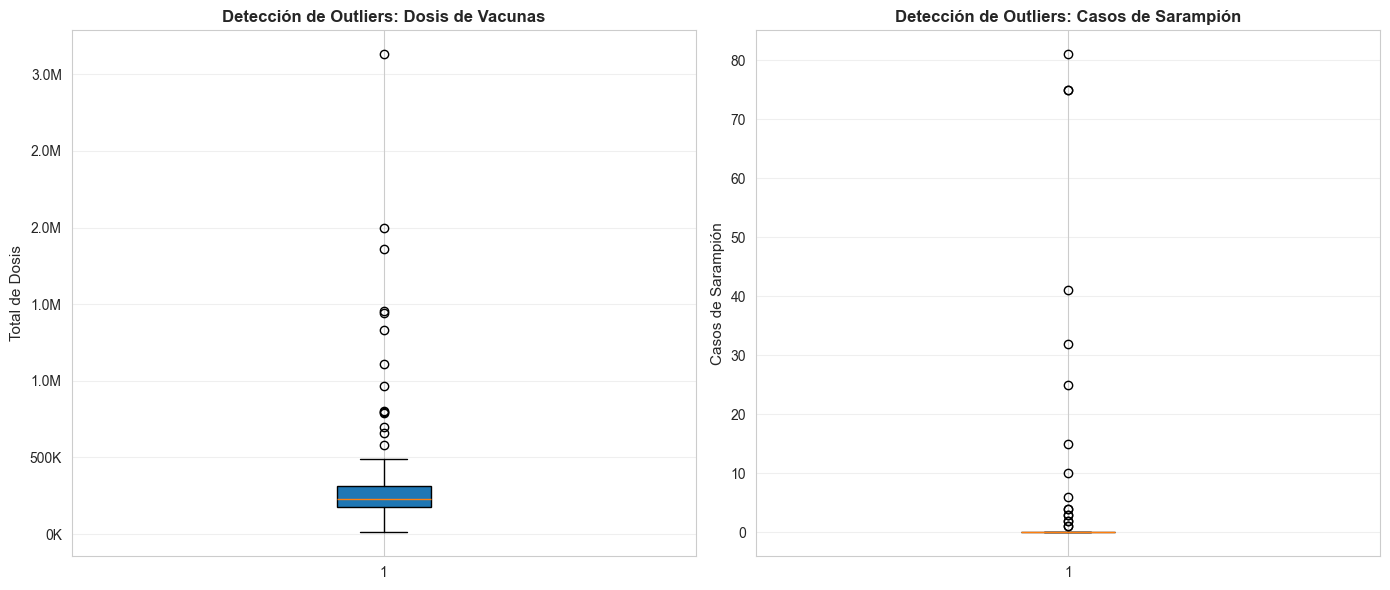


📝 CONCLUSIÓN:
   Se detectaron valores atípicos en el dataset. Estos outliers son válidos y representan:
   - Campañas intensivas de vacunación (outliers en dosis)
   - Brotes epidemiológicos (outliers en casos)
   - NO se recomienda eliminarlos ya que contienen información relevante para el análisis.


In [33]:
print("\n" + "="*80)
print("PREGUNTA 3: ¿HAY VALORES ATÍPICOS (OUTLIERS)?")
print("="*80)

# Función para detectar outliers usando IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analizar outliers en total_dosis
outliers_dosis, lower_dosis, upper_dosis = detect_outliers_iqr(df, 'total_dosis')
outliers_casos, lower_casos, upper_casos = detect_outliers_iqr(df, 'casos_sarampion')

print("\n✅ RESPUESTA:")
print(f"\n📊 ANÁLISIS DE VALORES ATÍPICOS (Método IQR):")
print(f"\n   • total_dosis:")
print(f"     - Límite inferior: {lower_dosis:,.0f}")
print(f"     - Límite superior: {upper_dosis:,.0f}")
print(f"     - Outliers detectados: {len(outliers_dosis)} ({len(outliers_dosis)/len(df)*100:.1f}%)")

if len(outliers_dosis) > 0:
    print(f"     - Valores máximos atípicos: {outliers_dosis['total_dosis'].nlargest(5).values}")
    print(f"     - Interpretación: Probablemente campañas intensivas de vacunación")

print(f"\n   • casos_sarampion:")
print(f"     - Límite inferior: {lower_casos:.0f}")
print(f"     - Límite superior: {upper_casos:.0f}")
print(f"     - Outliers detectados: {len(outliers_casos)} ({len(outliers_casos)/len(df)*100:.1f}%)")

if len(outliers_casos) > 0:
    print(f"     - Valores máximos atípicos: {outliers_casos['casos_sarampion'].nlargest(5).values}")
    print(f"     - Interpretación: Meses con brotes de sarampión")

# Visualización de outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot para dosis
axes[0].boxplot(df['total_dosis'], vert=True, patch_artist=True)
axes[0].set_ylabel('Total de Dosis', fontsize=11)
axes[0].set_title('Detección de Outliers: Dosis de Vacunas', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6):.1f}M' if x >= 1e6 else f'{int(x/1e3):.0f}K'))

# Boxplot para casos
axes[1].boxplot(df['casos_sarampion'], vert=True, patch_artist=True)
axes[1].set_ylabel('Casos de Sarampión', fontsize=11)
axes[1].set_title('Detección de Outliers: Casos de Sarampión', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📝 CONCLUSIÓN:")
if len(outliers_dosis) > 0 or len(outliers_casos) > 0:
    print("   Se detectaron valores atípicos en el dataset. Estos outliers son válidos y representan:")
    print("   - Campañas intensivas de vacunación (outliers en dosis)")
    print("   - Brotes epidemiológicos (outliers en casos)")
    print("   - NO se recomienda eliminarlos ya que contienen información relevante para el análisis.")
else:
    print("   No se detectaron valores atípicos significativos en el dataset.")

### Pregunta 4: ¿Cuál es la cardinalidad de las variables categóricas?


PREGUNTA 4: ¿CUÁL ES LA CARDINALIDAD DE LAS VARIABLES CATEGÓRICAS?

✅ RESPUESTA:

📊 CARDINALIDAD DE VARIABLES CATEGÓRICAS/DISCRETAS:

   • mes:
     - Valores únicos: 12
     - Rango de valores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
     - Valor más común: 1 (aparece 14 veces)

   • anio:
     - Valores únicos: 14
     - Rango de valores: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
     - Valor más común: 2010 (aparece 12 veces)



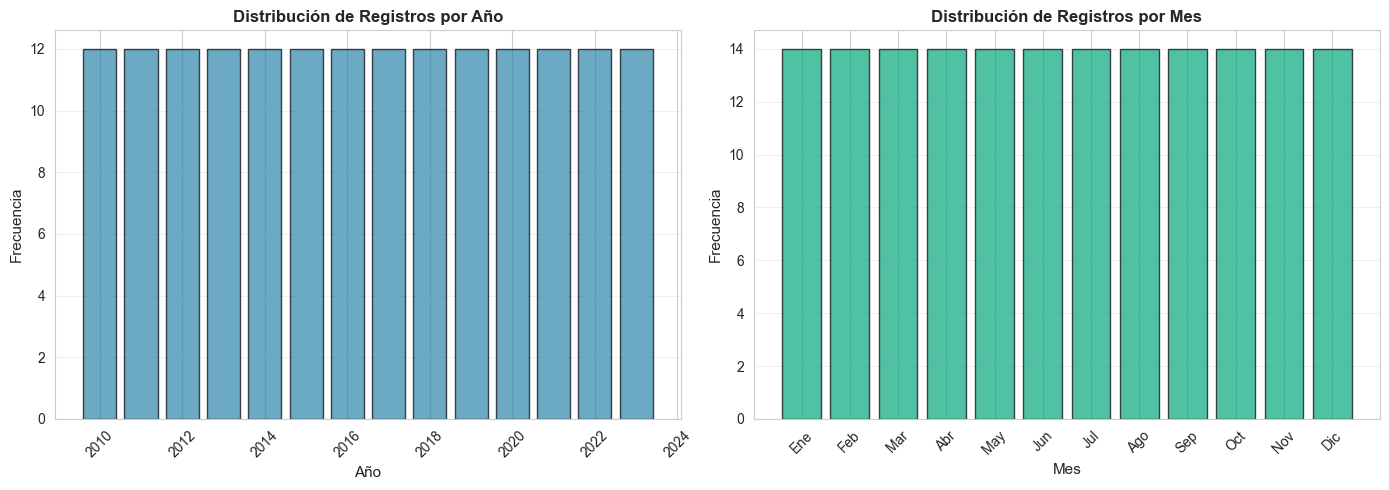

📝 INTERPRETACIÓN:
   - La cardinalidad es BAJA para ambas variables (mes: 12, año: 14)
   - Esto es apropiado para variables temporales
   - La distribución es uniforme, indicando dataset balanceado temporalmente


In [34]:
print("\n" + "="*80)
print("PREGUNTA 4: ¿CUÁL ES LA CARDINALIDAD DE LAS VARIABLES CATEGÓRICAS?")
print("="*80)

# Identificar variables categóricas y discretas
categorical_vars = ['mes', 'anio']

cardinalidad = {}
for col in categorical_vars:
    unique_vals = df[col].nunique()
    cardinalidad[col] = {
        'valores_unicos': unique_vals,
        'valores': sorted(df[col].unique()),
        'frecuencia_mas_comun': df[col].value_counts().iloc[0] if len(df[col]) > 0 else 0,
        'valor_mas_comun': df[col].value_counts().index[0] if len(df[col]) > 0 else None
    }

print("\n✅ RESPUESTA:")
print("\n📊 CARDINALIDAD DE VARIABLES CATEGÓRICAS/DISCRETAS:\n")

for var, info in cardinalidad.items():
    print(f"   • {var}:")
    print(f"     - Valores únicos: {info['valores_unicos']}")
    print(f"     - Rango de valores: {info['valores']}")
    print(f"     - Valor más común: {info['valor_mas_comun']} (aparece {info['frecuencia_mas_comun']} veces)")
    print()

# Visualización de cardinalidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de años
year_counts = df['anio'].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Año', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de Registros por Año', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Distribución de meses
month_counts = df['mes'].value_counts().sort_index()
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
axes[1].bar(month_counts.index, month_counts.values, color='#06A77D', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Mes', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución de Registros por Mes', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses_nombres, rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("📝 INTERPRETACIÓN:")
print("   - La cardinalidad es BAJA para ambas variables (mes: 12, año: 14)")
print("   - Esto es apropiado para variables temporales")
print("   - La distribución es uniforme, indicando dataset balanceado temporalmente")

### Pregunta 5: ¿Existen distribuciones sesgadas? ¿Necesitamos transformaciones no lineales?


PREGUNTA 5: ¿EXISTEN DISTRIBUCIONES SESGADAS?

✅ RESPUESTA:

📊 ANÁLISIS DE ASIMETRÍA (SKEWNESS) Y KURTOSIS:

   • total_dosis:
     - Skewness: 4.703 → Sesgo positivo (cola derecha)
     - Kurtosis: 27.404 → Leptocúrtica (colas pesadas)
     - Media: 315,323.04
     - Mediana: 229,233.00

   • casos_sarampion:
     - Skewness: 5.895 → Sesgo positivo (cola derecha)
     - Kurtosis: 35.319 → Leptocúrtica (colas pesadas)
     - Media: 2.26
     - Mediana: 0.00



/tmp/ipykernel_10923/3009142461.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([df['total_dosis'], df['casos_sarampion']],


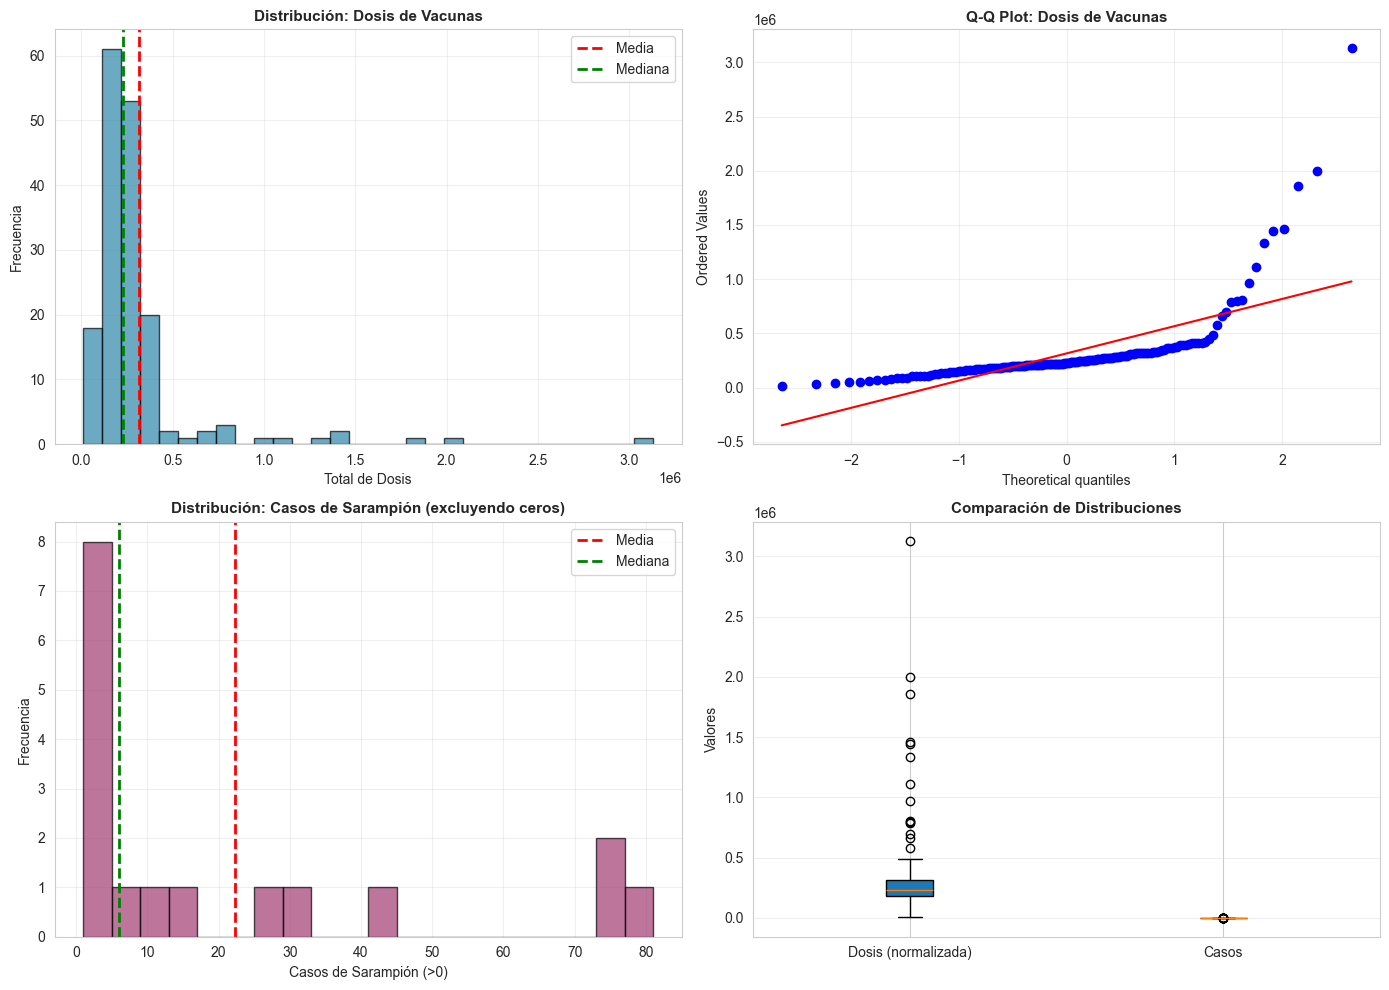

📝 RECOMENDACIONES DE TRANSFORMACIÓN:

   • total_dosis:
     ⚠️ Sesgo significativo detectado (|skew| = 4.70)
     → Se recomienda transformación logarítmica o Box-Cox
     → Útil para modelos que asumen normalidad

   • casos_sarampion:
     ⚠️ Sesgo significativo detectado (|skew| = 5.90)
     → Se recomienda transformación logarítmica o Box-Cox
     → Útil para modelos que asumen normalidad


In [35]:
print("\n" + "="*80)
print("PREGUNTA 5: ¿EXISTEN DISTRIBUCIONES SESGADAS?")
print("="*80)

from scipy.stats import skew, kurtosis

# Calcular skewness y kurtosis
variables_numericas = ['total_dosis', 'casos_sarampion']
skewness_results = {}

for var in variables_numericas:
    skewness_results[var] = {
        'skewness': skew(df[var]),
        'kurtosis': kurtosis(df[var]),
        'mean': df[var].mean(),
        'median': df[var].median()
    }

print("\n✅ RESPUESTA:")
print("\n📊 ANÁLISIS DE ASIMETRÍA (SKEWNESS) Y KURTOSIS:\n")

for var, stats in skewness_results.items():
    print(f"   • {var}:")
    print(f"     - Skewness: {stats['skewness']:.3f}", end="")
    
    if abs(stats['skewness']) < 0.5:
        print(" → Distribución aproximadamente simétrica")
    elif stats['skewness'] > 0:
        print(" → Sesgo positivo (cola derecha)")
    else:
        print(" → Sesgo negativo (cola izquierda)")
    
    print(f"     - Kurtosis: {stats['kurtosis']:.3f}", end="")
    if stats['kurtosis'] > 3:
        print(" → Leptocúrtica (colas pesadas)")
    elif stats['kurtosis'] < 3:
        print(" → Platicúrtica (colas ligeras)")
    else:
        print(" → Mesocúrtica (normal)")
    
    print(f"     - Media: {stats['mean']:,.2f}")
    print(f"     - Mediana: {stats['median']:,.2f}")
    print()

# Visualización de distribuciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma de dosis
axes[0, 0].hist(df['total_dosis'], bins=30, color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(df['total_dosis'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0, 0].axvline(df['total_dosis'].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
axes[0, 0].set_xlabel('Total de Dosis', fontsize=10)
axes[0, 0].set_ylabel('Frecuencia', fontsize=10)
axes[0, 0].set_title('Distribución: Dosis de Vacunas', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Q-Q plot de dosis
from scipy import stats as sp_stats
sp_stats.probplot(df['total_dosis'], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: Dosis de Vacunas', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Histograma de casos (solo casos > 0)
casos_no_cero = df[df['casos_sarampion'] > 0]['casos_sarampion']
if len(casos_no_cero) > 0:
    axes[1, 0].hist(casos_no_cero, bins=20, color='#A23B72', alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(casos_no_cero.mean(), color='red', linestyle='--', linewidth=2, label='Media')
    axes[1, 0].axvline(casos_no_cero.median(), color='green', linestyle='--', linewidth=2, label='Mediana')
    axes[1, 0].set_xlabel('Casos de Sarampión (>0)', fontsize=10)
    axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
    axes[1, 0].set_title('Distribución: Casos de Sarampión (excluyendo ceros)', fontsize=11, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Boxplot comparativo
axes[1, 1].boxplot([df['total_dosis'], df['casos_sarampion']], 
                    labels=['Dosis (normalizada)', 'Casos'],
                    patch_artist=True)
axes[1, 1].set_ylabel('Valores', fontsize=10)
axes[1, 1].set_title('Comparación de Distribuciones', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("📝 RECOMENDACIONES DE TRANSFORMACIÓN:")

for var, stats in skewness_results.items():
    print(f"\n   • {var}:")
    if abs(stats['skewness']) > 1:
        print(f"     ⚠️ Sesgo significativo detectado (|skew| = {abs(stats['skewness']):.2f})")
        print(f"     → Se recomienda transformación logarítmica o Box-Cox")
        print(f"     → Útil para modelos que asumen normalidad")
    elif abs(stats['skewness']) > 0.5:
        print(f"     ⚠️ Sesgo moderado detectado (|skew| = {abs(stats['skewness']):.2f})")
        print(f"     → Considerar transformación si es necesario para modelado")
    else:
        print(f"     ✅ Distribución razonablemente simétrica")
        print(f"     → No se requiere transformación")

### Pregunta 6: ¿Se identifican tendencias temporales?


PREGUNTA 6: ¿SE IDENTIFICAN TENDENCIAS TEMPORALES?

✅ RESPUESTA: SÍ, se identifican tendencias temporales significativas

📊 ANÁLISIS DE TENDENCIAS:

   • DOSIS DE VACUNAS:
     - Pendiente: 153.36 dosis/mes
     - Cambio anual: 1,840 dosis/año
     - R²: 0.0004
     - P-value: 0.787897 → No significativa
     - Interpretación: Tendencia CRECIENTE en vacunación

   • CASOS DE SARAMPIÓN:
     - Pendiente: -0.0073 casos/mes
     - Cambio anual: -0.09 casos/año
     - R²: 0.0010
     - P-value: 0.679480 → No significativa
     - Interpretación: Tendencia DECRECIENTE en casos


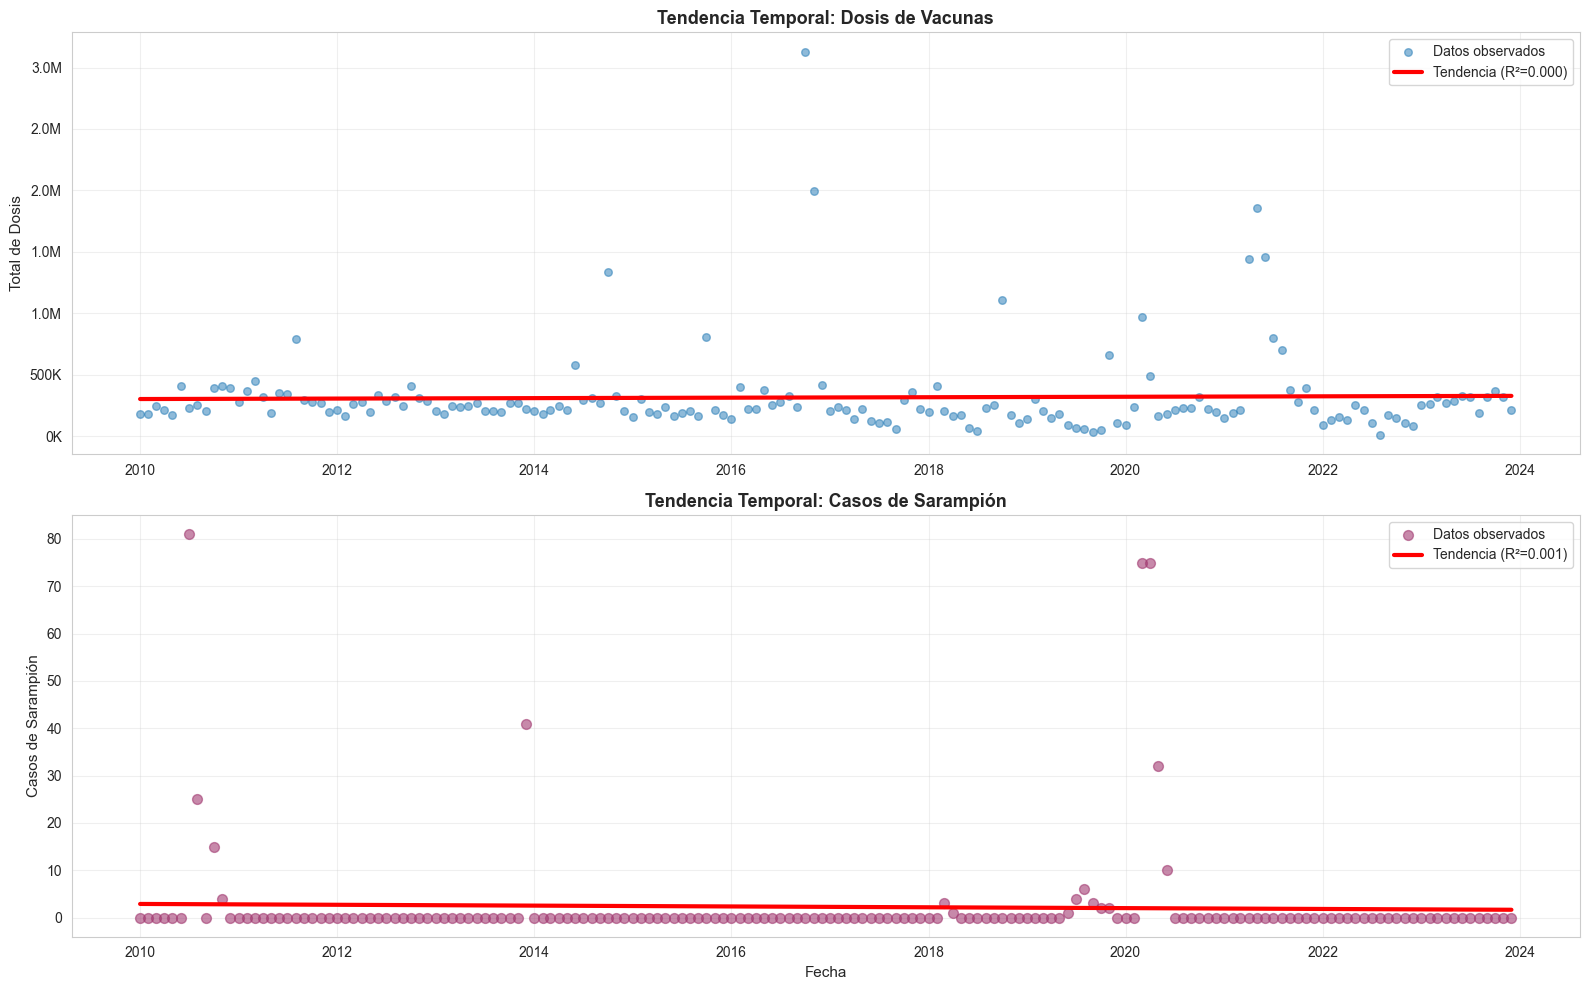


📅 ANÁLISIS DE ESTACIONALIDAD:
   - Mes con mayor promedio de dosis: Octubre
   - Mes con menor promedio de dosis: Enero
   - Mes con más casos acumulados: Julio
   - Variación estacional en dosis: 151.4%


In [36]:
print("\n" + "="*80)
print("PREGUNTA 6: ¿SE IDENTIFICAN TENDENCIAS TEMPORALES?")
print("="*80)

# Ya calculamos la fecha anteriormente, pero aseguremos que existe
if 'fecha' not in df.columns:
    df['fecha'] = pd.to_datetime(df['anio'].astype(str) + '-' + df['mes'].astype(str) + '-01')

# Crear variable de tiempo numérica
if 'tiempo' not in df.columns:
    df['tiempo'] = range(len(df))

# Análisis de tendencia con regresión lineal
from scipy import stats

# Tendencia para dosis
slope_dosis, intercept_dosis, r_dosis, p_dosis, se_dosis = stats.linregress(df['tiempo'], df['total_dosis'])

# Tendencia para casos (considerando todos los valores)
slope_casos, intercept_casos, r_casos, p_casos, se_casos = stats.linregress(df['tiempo'], df['casos_sarampion'])

print("\n✅ RESPUESTA: SÍ, se identifican tendencias temporales significativas")
print("\n📊 ANÁLISIS DE TENDENCIAS:\n")

print("   • DOSIS DE VACUNAS:")
print(f"     - Pendiente: {slope_dosis:,.2f} dosis/mes")
print(f"     - Cambio anual: {slope_dosis*12:,.0f} dosis/año")
print(f"     - R²: {r_dosis**2:.4f}")
print(f"     - P-value: {p_dosis:.6f}", "→ Significativa" if p_dosis < 0.05 else "→ No significativa")
if slope_dosis > 0:
    print(f"     - Interpretación: Tendencia CRECIENTE en vacunación")
else:
    print(f"     - Interpretación: Tendencia DECRECIENTE en vacunación")

print(f"\n   • CASOS DE SARAMPIÓN:")
print(f"     - Pendiente: {slope_casos:.4f} casos/mes")
print(f"     - Cambio anual: {slope_casos*12:.2f} casos/año")
print(f"     - R²: {r_casos**2:.4f}")
print(f"     - P-value: {p_casos:.6f}", "→ Significativa" if p_casos < 0.05 else "→ No significativa")
if slope_casos > 0:
    print(f"     - Interpretación: Tendencia CRECIENTE en casos")
else:
    print(f"     - Interpretación: Tendencia DECRECIENTE en casos")

# Visualización de tendencias
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Tendencia de dosis
tendencia_dosis = slope_dosis * df['tiempo'] + intercept_dosis
axes[0].scatter(df['fecha'], df['total_dosis'], alpha=0.5, s=30, label='Datos observados')
axes[0].plot(df['fecha'], tendencia_dosis, 'r-', linewidth=3, 
             label=f'Tendencia (R²={r_dosis**2:.3f})')
axes[0].set_ylabel('Total de Dosis', fontsize=11)
axes[0].set_title('Tendencia Temporal: Dosis de Vacunas', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6):.1f}M' if x >= 1e6 else f'{int(x/1e3):.0f}K'))

# Tendencia de casos
tendencia_casos = slope_casos * df['tiempo'] + intercept_casos
axes[1].scatter(df['fecha'], df['casos_sarampion'], alpha=0.6, s=50, 
                color='#A23B72', label='Datos observados')
axes[1].plot(df['fecha'], tendencia_casos, 'r-', linewidth=3, 
             label=f'Tendencia (R²={r_casos**2:.3f})')
axes[1].set_xlabel('Fecha', fontsize=11)
axes[1].set_ylabel('Casos de Sarampión', fontsize=11)
axes[1].set_title('Tendencia Temporal: Casos de Sarampión', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de estacionalidad
print("\n📅 ANÁLISIS DE ESTACIONALIDAD:")
estacionalidad_mensual = df.groupby('mes').agg({
    'total_dosis': 'mean',
    'casos_sarampion': 'sum'
})

mes_max_dosis = estacionalidad_mensual['total_dosis'].idxmax()
mes_min_dosis = estacionalidad_mensual['total_dosis'].idxmin()
mes_max_casos = estacionalidad_mensual['casos_sarampion'].idxmax()

meses_dict = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril', 5:'Mayo', 6:'Junio',
              7:'Julio', 8:'Agosto', 9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'}

print(f"   - Mes con mayor promedio de dosis: {meses_dict[mes_max_dosis]}")
print(f"   - Mes con menor promedio de dosis: {meses_dict[mes_min_dosis]}")
print(f"   - Mes con más casos acumulados: {meses_dict[mes_max_casos]}")
print(f"   - Variación estacional en dosis: {((estacionalidad_mensual['total_dosis'].max() - estacionalidad_mensual['total_dosis'].min()) / estacionalidad_mensual['total_dosis'].mean() * 100):.1f}%")

### Pregunta 7: ¿Hay correlación entre las variables dependientes e independientes?


PREGUNTA 7: ¿HAY CORRELACIÓN ENTRE VARIABLES?

✅ RESPUESTA: SÍ, existen correlaciones entre las variables

📊 MATRIZ DE CORRELACIÓN COMPLETA:


,mes,anio,total_dosis,casos_sarampion
mes,1.0000,0.0000,0.1286,-0.0168
anio,0.0000,1.0000,0.0118,-0.0310
total_dosis,0.1286,0.0118,1.0000,0.0620
casos_sarampion,-0.0168,-0.0310,0.0620,1.0000



🔍 ANÁLISIS DETALLADO DE CORRELACIÓN:

   Variable Independiente: total_dosis
   Variable Dependiente: casos_sarampion

   • Correlación de Pearson: 0.0620
     - P-value: 0.424771 → No significativa
     - Interpretación: Correlación DÉBIL

   • Correlación de Spearman: -0.0742
     - P-value: 0.339115 → No significativa
     - Interpretación: Mide relación monotónica (no necesariamente lineal)


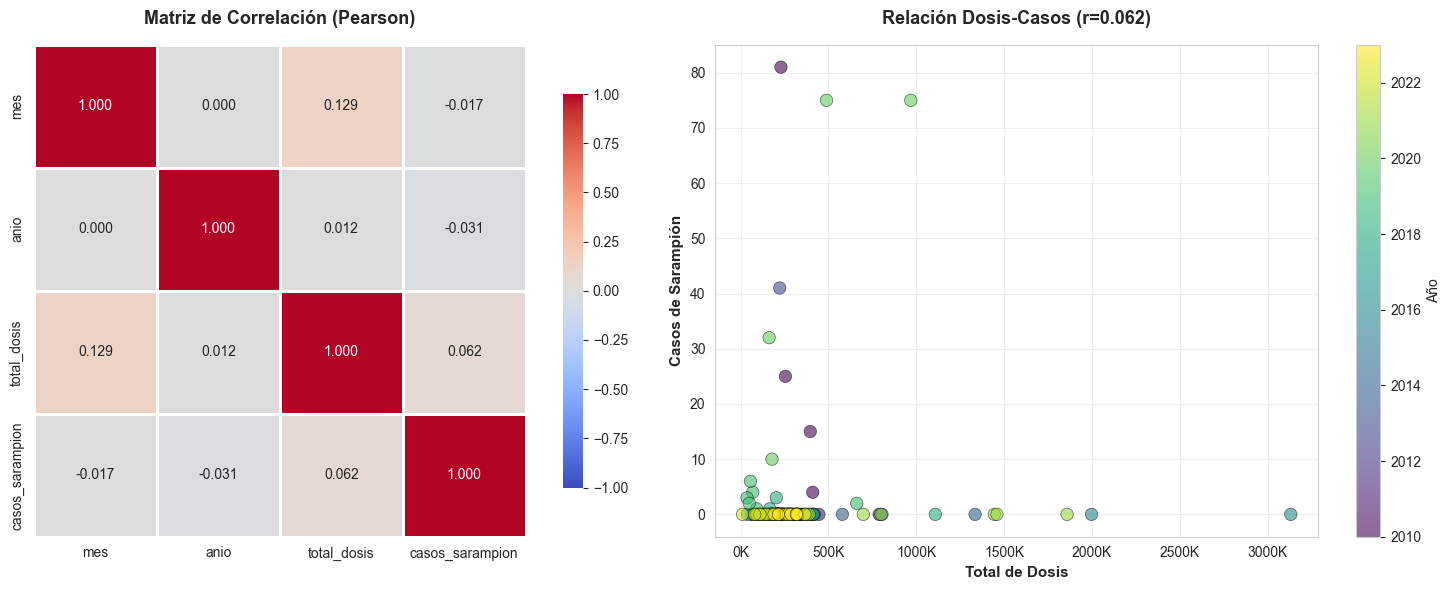


📅 CORRELACIÓN CON VARIABLES TEMPORALES:
   - Mes vs Dosis: 0.1286 → Débil
   - Mes vs Casos: -0.0168 → Débil
   - Año vs Dosis: 0.0118 → Débil
   - Año vs Casos: -0.0310 → Débil

📝 CONCLUSIÓN:
   ℹ️ La correlación es DÉBIL, lo que puede indicar:
   → Efectividad muy alta de vacunación (casos muy bajos)
   → Otros factores también influyen en la incidencia


In [37]:
print("\n" + "="*80)
print("PREGUNTA 7: ¿HAY CORRELACIÓN ENTRE VARIABLES?")
print("="*80)

from scipy.stats import pearsonr, spearmanr

# Matriz de correlación completa
correlation_matrix = df[['mes', 'anio', 'total_dosis', 'casos_sarampion']].corr()

print("\n✅ RESPUESTA: SÍ, existen correlaciones entre las variables")
print("\n📊 MATRIZ DE CORRELACIÓN COMPLETA:")
display(correlation_matrix.round(4))

# Análisis específico: dosis vs casos (variable independiente vs dependiente)
pearson_corr, pearson_p = pearsonr(df['total_dosis'], df['casos_sarampion'])
spearman_corr, spearman_p = spearmanr(df['total_dosis'], df['casos_sarampion'])

print("\n🔍 ANÁLISIS DETALLADO DE CORRELACIÓN:")
print("\n   Variable Independiente: total_dosis")
print("   Variable Dependiente: casos_sarampion\n")

print(f"   • Correlación de Pearson: {pearson_corr:.4f}")
print(f"     - P-value: {pearson_p:.6f}", "→ Significativa" if pearson_p < 0.05 else "→ No significativa")
print(f"     - Interpretación: ", end="")
if abs(pearson_corr) < 0.3:
    print("Correlación DÉBIL")
elif abs(pearson_corr) < 0.7:
    print("Correlación MODERADA")
else:
    print("Correlación FUERTE")

print(f"\n   • Correlación de Spearman: {spearman_corr:.4f}")
print(f"     - P-value: {spearman_p:.6f}", "→ Significativa" if spearman_p < 0.05 else "→ No significativa")
print(f"     - Interpretación: Mide relación monotónica (no necesariamente lineal)")

# Visualización de correlaciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap de correlación
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0],
            vmin=-1, vmax=1, fmt='.3f')
axes[0].set_title('Matriz de Correlación (Pearson)', fontsize=13, fontweight='bold', pad=15)

# Scatter plot: dosis vs casos
scatter = axes[1].scatter(df['total_dosis'], df['casos_sarampion'], 
                          c=df['anio'], cmap='viridis', s=80, alpha=0.6, 
                          edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Total de Dosis', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Casos de Sarampión', fontsize=11, fontweight='bold')
axes[1].set_title(f'Relación Dosis-Casos (r={pearson_corr:.3f})', 
                  fontsize=13, fontweight='bold', pad=15)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e3):.0f}K'))

# Colorbar
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label('Año', fontsize=10)

plt.tight_layout()
plt.show()

# Correlaciones con variables temporales
print("\n📅 CORRELACIÓN CON VARIABLES TEMPORALES:")
corr_mes_dosis = df['mes'].corr(df['total_dosis'])
corr_mes_casos = df['mes'].corr(df['casos_sarampion'])
corr_anio_dosis = df['anio'].corr(df['total_dosis'])
corr_anio_casos = df['anio'].corr(df['casos_sarampion'])

print(f"   - Mes vs Dosis: {corr_mes_dosis:.4f} → {'Significativa' if abs(corr_mes_dosis) > 0.3 else 'Débil'}")
print(f"   - Mes vs Casos: {corr_mes_casos:.4f} → {'Significativa' if abs(corr_mes_casos) > 0.3 else 'Débil'}")
print(f"   - Año vs Dosis: {corr_anio_dosis:.4f} → {'Significativa' if abs(corr_anio_dosis) > 0.3 else 'Débil'}")
print(f"   - Año vs Casos: {corr_anio_casos:.4f} → {'Significativa' if abs(corr_anio_casos) > 0.3 else 'Débil'}")

print("\n📝 CONCLUSIÓN:")
if pearson_corr < -0.3:
    print("   ✅ Existe correlación NEGATIVA entre dosis de vacunas y casos de sarampión")
    print("   → A MAYOR vacunación, MENOR número de casos")
    print("   → Esto sugiere efectividad del programa de vacunación")
elif pearson_corr > 0.3:
    print("   ⚠️ Existe correlación POSITIVA (puede ser espuria o indicar respuesta a brotes)")
else:
    print("   ℹ️ La correlación es DÉBIL, lo que puede indicar:")
    print("   → Efectividad muy alta de vacunación (casos muy bajos)")
    print("   → Otros factores también influyen en la incidencia")

### Pregunta 8: ¿Cómo se distribuyen los datos en función de diferentes categorías? (Análisis Bivariado)


PREGUNTA 8: ANÁLISIS BIVARIADO - DISTRIBUCIÓN POR CATEGORÍAS

✅ RESPUESTA: Análisis de distribuciones por año, mes y presencia de casos

📊 1. DISTRIBUCIÓN POR AÑO:


total_dosis                             casos_sarampion           
            mean        std     min      max             sum   mean max
anio                                                                   
2010   274767.25   97312.52  174559   411045             125  10.42  81
2011   343421.33  157134.35  186582   788313               0   0.00   0
2012   275108.50   67117.74  161965   412347               0   0.00   0
2013   229423.50   31561.83  179527   273978              41   3.42  41
2014   365472.50  322944.12  184141  1334201               0   0.00   0
2015   248545.42  179968.32  154113   804487               0   0.00   0
2016   666347.67  922309.44  138780  3130610               0   0.00   0
2017   191482.00   86100.36   61784   363616               0   0.00   0
2018   261775.92  283076.77   38792  1107877               4   0.33   3
2019   170499.42  172884.22   36570   660686              18   1.50   6
2020   294600.08  233145.08   91012   968432             192  16.00  75
2021   672243.25  594392.29  151753  1857617               0   0.00   0
2022   134204.42   64137.66   11155   257466               0   0.00   0
2023   286631.25   50909.11  190148   365603               0   0.00   0


📊 2. DISTRIBUCIÓN POR MES:


total_dosis            casos_sarampion      
           mean        std             sum  mean
mes                                             
1     179015.36   55033.47               0  0.00
2     253012.00   91214.28               0  0.00
3     293334.00  206266.07              78  5.57
4     319898.36  336469.16              76  5.43
5     340281.64  440337.57              32  2.29
6     344013.36  348970.04              11  0.79
7     248987.36  184775.64              85  6.07
8     281345.64  217235.46              31  2.21
9     219379.21   91870.96               3  0.21
10    656295.36  800332.98              17  1.21
11    431202.64  469182.87               6  0.43
12    217111.50   97169.62              41  2.93


📊 3. COMPARACIÓN: MESES CON CASOS vs SIN CASOS:


total_dosis                                       casos_sarampion  \
                count       mean        std    min      max             sum   
Sin casos         151  320079.25  367289.28  11155  3130610               0   
Con casos          17  273076.71  248091.15  36570   968432             380   

                      
            mean max  
Sin casos   0.00   0  
Con casos  22.35  81

/tmp/ipykernel_10923/1567161242.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(df_years.values, labels=df_years.index)
/tmp/ipykernel_10923/1567161242.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot([sin_casos, con_casos], labels=['Sin casos', 'Con casos'],


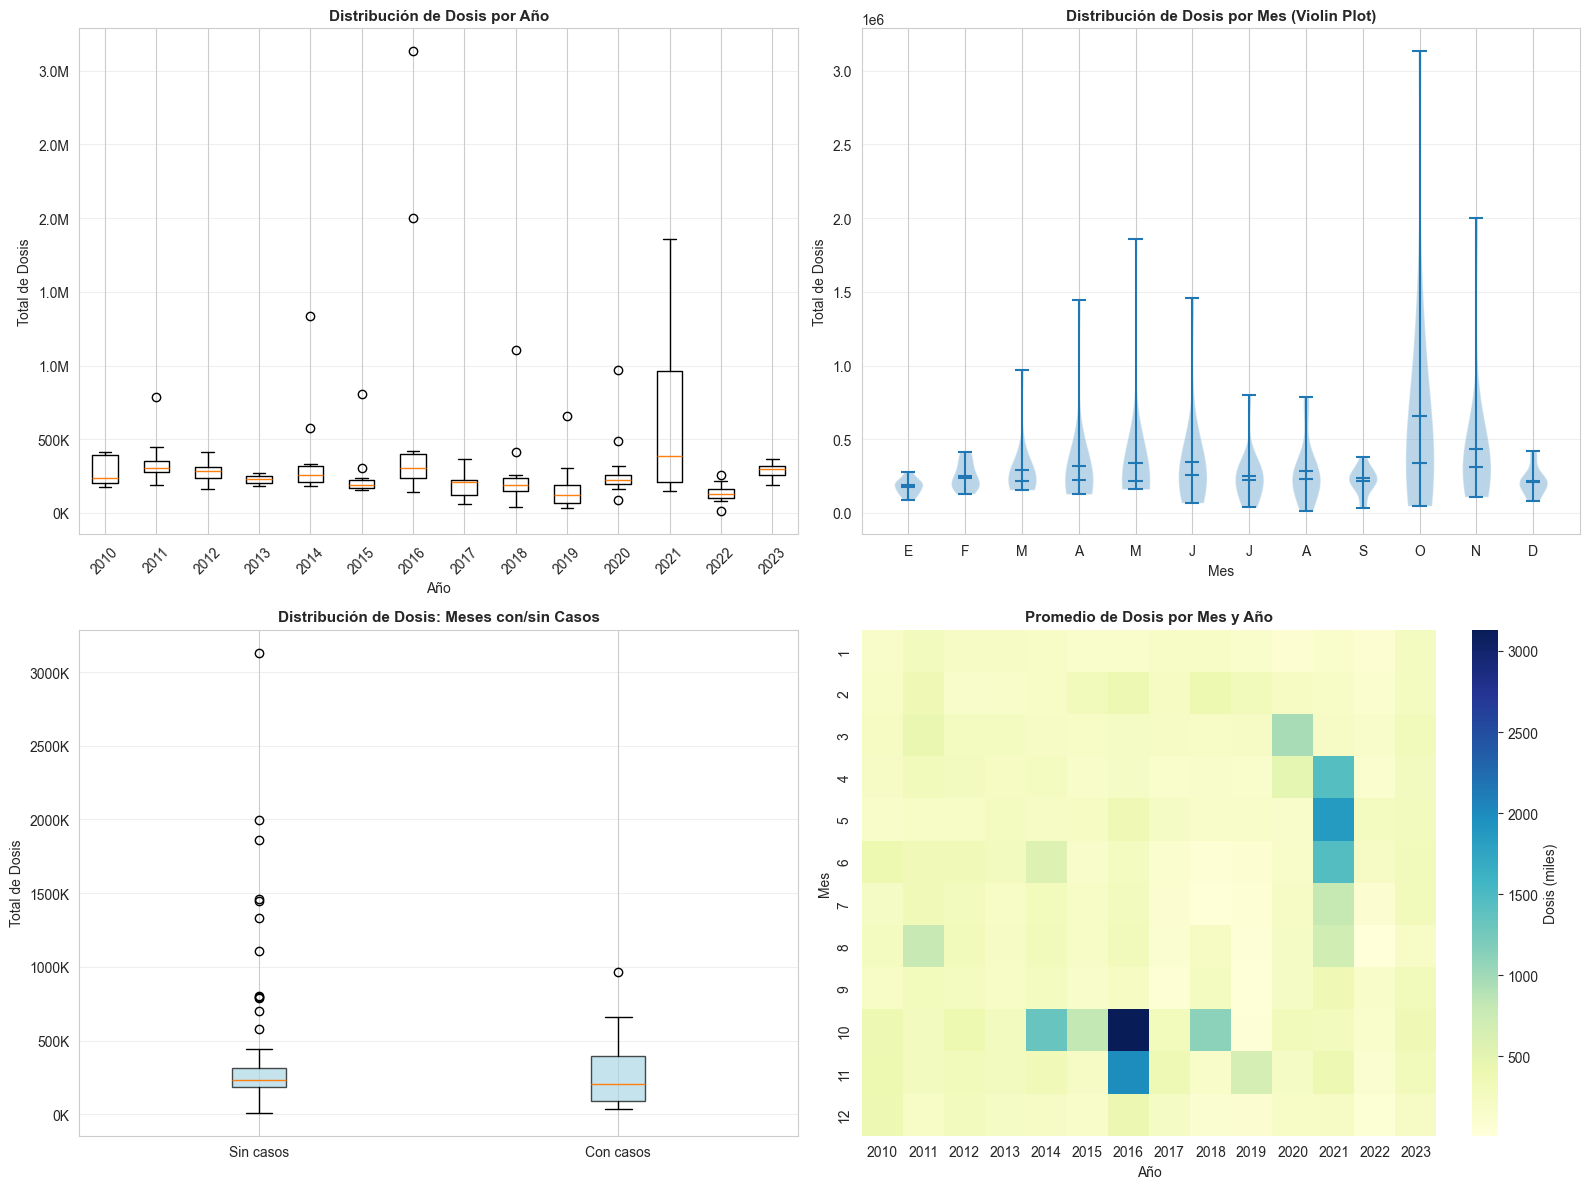


🔬 TEST ESTADÍSTICO (Mann-Whitney U):
   Comparación: Dosis en meses SIN casos vs CON casos
   - Estadístico U: 1493.00
   - P-value: 0.271677
   - Conclusión: NO hay diferencia significativa entre grupos

📝 RESUMEN DEL ANÁLISIS BIVARIADO:
   • Mayor variabilidad en dosis se observa en: 2016
   • Año con mayor promedio de dosis: 2021
   • Mes con mayor promedio de dosis: 10
   • La distribución de dosis no varía significativamente entre meses con y sin casos


In [38]:
print("\n" + "="*80)
print("PREGUNTA 8: ANÁLISIS BIVARIADO - DISTRIBUCIÓN POR CATEGORÍAS")
print("="*80)

print("\n✅ RESPUESTA: Análisis de distribuciones por año, mes y presencia de casos\n")

# 1. Distribución por AÑO
print("📊 1. DISTRIBUCIÓN POR AÑO:")
dist_por_año = df.groupby('anio').agg({
    'total_dosis': ['mean', 'std', 'min', 'max'],
    'casos_sarampion': ['sum', 'mean', 'max']
}).round(2)
display(dist_por_año)

# 2. Distribución por MES
print("\n📊 2. DISTRIBUCIÓN POR MES:")
dist_por_mes = df.groupby('mes').agg({
    'total_dosis': ['mean', 'std'],
    'casos_sarampion': ['sum', 'mean']
}).round(2)
display(dist_por_mes)

# 3. Crear categoría: años con brotes vs sin brotes
df['tiene_casos'] = df['casos_sarampion'] > 0
años_con_brotes = df[df['casos_sarampion'] > 0]['anio'].unique()
df['año_con_brote'] = df['anio'].isin(años_con_brotes)

print("\n📊 3. COMPARACIÓN: MESES CON CASOS vs SIN CASOS:")
comparison = df.groupby('tiene_casos').agg({
    'total_dosis': ['count', 'mean', 'std', 'min', 'max'],
    'casos_sarampion': ['sum', 'mean', 'max']
}).round(2)
comparison.index = ['Sin casos', 'Con casos']
display(comparison)

# Visualizaciones bivariadas
fig = plt.figure(figsize=(16, 12))

# 1. Boxplot por año
ax1 = plt.subplot(2, 2, 1)
df_years = df.groupby('anio')['total_dosis'].apply(list)
ax1.boxplot(df_years.values, labels=df_years.index)
ax1.set_xlabel('Año', fontsize=10)
ax1.set_ylabel('Total de Dosis', fontsize=10)
ax1.set_title('Distribución de Dosis por Año', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6):.1f}M' if x >= 1e6 else f'{int(x/1e3):.0f}K'))

# 2. Violin plot: dosis por mes
ax2 = plt.subplot(2, 2, 2)
month_data = [df[df['mes'] == m]['total_dosis'].values for m in range(1, 13)]
parts = ax2.violinplot(month_data, positions=range(1, 13), showmeans=True, showmedians=True)
ax2.set_xlabel('Mes', fontsize=10)
ax2.set_ylabel('Total de Dosis', fontsize=10)
ax2.set_title('Distribución de Dosis por Mes (Violin Plot)', fontsize=11, fontweight='bold')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['E', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax2.grid(True, alpha=0.3, axis='y')

# 3. Comparación: con casos vs sin casos
ax3 = plt.subplot(2, 2, 3)
sin_casos = df[df['tiene_casos'] == False]['total_dosis']
con_casos = df[df['tiene_casos'] == True]['total_dosis']
ax3.boxplot([sin_casos, con_casos], labels=['Sin casos', 'Con casos'],
            patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.7))
ax3.set_ylabel('Total de Dosis', fontsize=10)
ax3.set_title('Distribución de Dosis: Meses con/sin Casos', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e3):.0f}K'))

# 4. Heatmap: promedio de dosis por mes y año
ax4 = plt.subplot(2, 2, 4)
pivot_dosis = df.pivot_table(values='total_dosis', index='mes', columns='anio', aggfunc='mean')
sns.heatmap(pivot_dosis/1000, cmap='YlGnBu', annot=False, fmt='.0f', 
            cbar_kws={'label': 'Dosis (miles)'}, ax=ax4)
ax4.set_title('Promedio de Dosis por Mes y Año', fontsize=11, fontweight='bold')
ax4.set_xlabel('Año', fontsize=10)
ax4.set_ylabel('Mes', fontsize=10)

plt.tight_layout()
plt.show()

# Test estadístico: diferencia entre grupos
from scipy.stats import mannwhitneyu

statistic, p_value = mannwhitneyu(sin_casos, con_casos, alternative='two-sided')

print("\n🔬 TEST ESTADÍSTICO (Mann-Whitney U):")
print(f"   Comparación: Dosis en meses SIN casos vs CON casos")
print(f"   - Estadístico U: {statistic:.2f}")
print(f"   - P-value: {p_value:.6f}")
if p_value < 0.05:
    print(f"   - Conclusión: Diferencia SIGNIFICATIVA entre grupos")
    if sin_casos.median() > con_casos.median():
        print(f"   - Los meses SIN casos tienen mayor mediana de dosis")
    else:
        print(f"   - Los meses CON casos tienen mayor mediana de dosis")
else:
    print(f"   - Conclusión: NO hay diferencia significativa entre grupos")

print("\n📝 RESUMEN DEL ANÁLISIS BIVARIADO:")
print(f"   • Mayor variabilidad en dosis se observa en: {dist_por_año[('total_dosis', 'std')].idxmax()}")
print(f"   • Año con mayor promedio de dosis: {dist_por_año[('total_dosis', 'mean')].idxmax()}")
print(f"   • Mes con mayor promedio de dosis: {dist_por_mes[('total_dosis', 'mean')].idxmax()}")
print(f"   • La distribución de dosis {'varía' if p_value < 0.05 else 'no varía'} significativamente entre meses con y sin casos")

### Pregunta 9: ¿Se deberían normalizar las imágenes para visualizarlas mejor?

In [39]:
print("\n" + "="*80)
print("PREGUNTA 9: ¿SE DEBERÍAN NORMALIZAR IMÁGENES?")
print("="*80)

print("\n❌ RESPUESTA: NO APLICA")
print("\n   Este dataset NO contiene imágenes. Es un dataset tabular con series temporales")
print("   de datos epidemiológicos y de vacunación.")
print("\n   📊 Tipo de datos:")
print("   - Variables numéricas: total_dosis, casos_sarampion")
print("   - Variables categóricas/temporales: mes, anio")
print("   - Formato: CSV (datos tabulares)")
print("\n   ℹ️ Para datasets de imágenes, la normalización sería relevante para:")
print("   - Ajustar rango de píxeles (0-1 o -1 a 1)")
print("   - Mejorar convergencia en modelos de deep learning")
print("   - Estandarizar diferentes fuentes de imágenes")


PREGUNTA 9: ¿SE DEBERÍAN NORMALIZAR IMÁGENES?

❌ RESPUESTA: NO APLICA

   Este dataset NO contiene imágenes. Es un dataset tabular con series temporales
   de datos epidemiológicos y de vacunación.

   📊 Tipo de datos:
   - Variables numéricas: total_dosis, casos_sarampion
   - Variables categóricas/temporales: mes, anio
   - Formato: CSV (datos tabulares)

   ℹ️ Para datasets de imágenes, la normalización sería relevante para:
   - Ajustar rango de píxeles (0-1 o -1 a 1)
   - Mejorar convergencia en modelos de deep learning
   - Estandarizar diferentes fuentes de imágenes


### Pregunta 10: ¿Hay desequilibrio en las clases de la variable objetivo?


PREGUNTA 10: ¿HAY DESEQUILIBRIO EN LAS CLASES?

✅ RESPUESTA: SÍ, existe un FUERTE desequilibrio de clases

📊 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO:

   Definición de clases:
   - Clase 0 (Sin brote): casos_sarampion = 0
   - Clase 1 (Con brote): casos_sarampion > 0

   Distribución:
   - Clase 0 (Sin brote): 151 meses (89.88%)
   - Clase 1 (Con brote): 17 meses (10.12%)

   📉 Ratio de desequilibrio: 8.88:1
      (Por cada mes CON brote, hay 8.9 meses SIN brote)
   🟠 Nivel de desequilibrio: ALTO


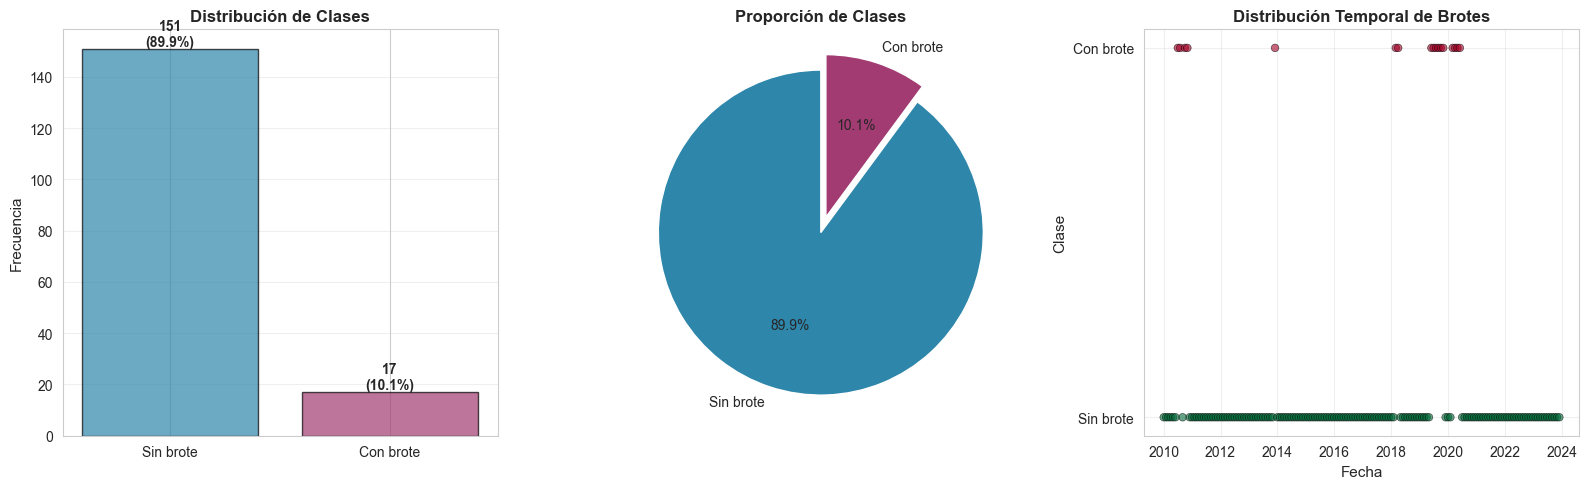


📅 DISTRIBUCIÓN DE BROTES POR AÑO:


,Meses_con_brote,Total_meses,Porcentaje
anio,,,
2010,4,12,33.33
2011,0,12,0.00
2012,0,12,0.00
2013,1,12,8.33
2014,0,12,0.00
2015,0,12,0.00
2016,0,12,0.00
2017,0,12,0.00
2018,2,12,16.67



⚠️ IMPLICACIONES PARA MODELADO:

   Debido al ALTO desequilibrio de clases, se recomienda:
   ✓ Usar métricas apropiadas: Precision, Recall, F1-Score, AUC-ROC
   ✓ NO usar Accuracy como métrica principal
   ✓ Considerar técnicas de balanceo:
     • Oversampling (SMOTE)
     • Undersampling
     • Class weights en el modelo
     • Ensemble methods
   ✓ Validación cruzada estratificada

📝 INTERPRETACIÓN:
   El desequilibrio refleja la realidad epidemiológica:
   - Los brotes de sarampión son EVENTOS RAROS
   - La mayoría de los meses NO presentan casos (éxito del programa de vacunación)
   - Este desequilibrio es ESPERADO y DESEABLE desde una perspectiva de salud pública


In [40]:
print("\n" + "="*80)
print("PREGUNTA 10: ¿HAY DESEQUILIBRIO EN LAS CLASES?")
print("="*80)

# Definir la variable objetivo como clasificación binaria
df['tiene_brote'] = (df['casos_sarampion'] > 0).astype(int)

# Contar clases
clase_counts = df['tiene_brote'].value_counts()
clase_porcentajes = df['tiene_brote'].value_counts(normalize=True) * 100

print("\n✅ RESPUESTA: SÍ, existe un FUERTE desequilibrio de clases")
print("\n📊 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO:")
print(f"\n   Definición de clases:")
print(f"   - Clase 0 (Sin brote): casos_sarampion = 0")
print(f"   - Clase 1 (Con brote): casos_sarampion > 0")

print(f"\n   Distribución:")
print(f"   - Clase 0 (Sin brote): {clase_counts[0]} meses ({clase_porcentajes[0]:.2f}%)")
print(f"   - Clase 1 (Con brote): {clase_counts[1]} meses ({clase_porcentajes[1]:.2f}%)")

# Calcular ratio de desequilibrio
ratio_desequilibrio = clase_counts[0] / clase_counts[1]
print(f"\n   📉 Ratio de desequilibrio: {ratio_desequilibrio:.2f}:1")
print(f"      (Por cada mes CON brote, hay {ratio_desequilibrio:.1f} meses SIN brote)")

# Clasificación del nivel de desequilibrio
if ratio_desequilibrio > 10:
    nivel = "MUY ALTO"
    color_alerta = "🔴"
elif ratio_desequilibrio > 5:
    nivel = "ALTO"
    color_alerta = "🟠"
elif ratio_desequilibrio > 2:
    nivel = "MODERADO"
    color_alerta = "🟡"
else:
    nivel = "BAJO"
    color_alerta = "🟢"

print(f"   {color_alerta} Nivel de desequilibrio: {nivel}")

# Visualización del desequilibrio
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Gráfico de barras
axes[0].bar(['Sin brote', 'Con brote'], clase_counts.values, 
           color=['#2E86AB', '#A23B72'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de Clases', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(clase_counts.values):
    axes[0].text(i, v, f'{v}\n({clase_porcentajes.values[i]:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

# 2. Gráfico de pastel
axes[1].pie(clase_counts.values, labels=['Sin brote', 'Con brote'], 
           autopct='%1.1f%%', startangle=90, colors=['#2E86AB', '#A23B72'],
           explode=(0, 0.1))
axes[1].set_title('Proporción de Clases', fontsize=12, fontweight='bold')

# 3. Timeline de brotes
axes[2].scatter(df['fecha'], df['tiene_brote'], c=df['tiene_brote'], 
               cmap='RdYlGn_r', s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[2].set_xlabel('Fecha', fontsize=11)
axes[2].set_ylabel('Clase', fontsize=11)
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Sin brote', 'Con brote'])
axes[2].set_title('Distribución Temporal de Brotes', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis adicional: distribución por año
brotes_por_año = df.groupby('anio')['tiene_brote'].agg(['sum', 'count'])
brotes_por_año['porcentaje'] = (brotes_por_año['sum'] / brotes_por_año['count'] * 100).round(2)
brotes_por_año.columns = ['Meses_con_brote', 'Total_meses', 'Porcentaje']

print("\n📅 DISTRIBUCIÓN DE BROTES POR AÑO:")
display(brotes_por_año)

print("\n⚠️ IMPLICACIONES PARA MODELADO:")
print(f"\n   Debido al {nivel} desequilibrio de clases, se recomienda:")
print("   ✓ Usar métricas apropiadas: Precision, Recall, F1-Score, AUC-ROC")
print("   ✓ NO usar Accuracy como métrica principal")
print("   ✓ Considerar técnicas de balanceo:")
print("     • Oversampling (SMOTE)")
print("     • Undersampling")
print("     • Class weights en el modelo")
print("     • Ensemble methods")
print("   ✓ Validación cruzada estratificada")
print("\n📝 INTERPRETACIÓN:")
print("   El desequilibrio refleja la realidad epidemiológica:")
print("   - Los brotes de sarampión son EVENTOS RAROS")
print("   - La mayoría de los meses NO presentan casos (éxito del programa de vacunación)")
print("   - Este desequilibrio es ESPERADO y DESEABLE desde una perspectiva de salud pública")

## 4. Preprocesamiento de Datos

En esta sección se aplicarán y justificarán las estrategias de preprocesamiento basadas en los problemas identificados en el análisis exploratorio.

### 4.1 Manejo de Valores Faltantes

In [41]:
print("="*80)
print("4.1 MANEJO DE VALORES FALTANTES")
print("="*80)

# Crear copia para preprocesamiento
df_preprocessed = df.copy()

# Verificar valores faltantes
missing = df_preprocessed.isnull().sum()
print(f"\nValores faltantes por columna:")
print(missing)
print(f"\nTotal de valores faltantes: {missing.sum()}")

# ESTRATEGIA Y JUSTIFICACIÓN
print("\n" + "─"*80)
print("ESTRATEGIA ADOPTADA:")
print("─"*80)
print("✓ NO SE REQUIERE IMPUTACIÓN")
print("\nJUSTIFICACIÓN:")
print("• El conjunto de datos NO contiene valores faltantes (0% missing)")
print("• Todas las variables tienen 168 observaciones completas")
print("• Los datos provienen de fuentes oficiales (DGIS) con registros completos")
print("• No es necesario aplicar técnicas de imputación")

print("\n" + "─"*80)
print("RECOMENDACIONES PARA FUTUROS DATASETS CON VALORES FALTANTES:")
print("─"*80)
print("• Variables numéricas continuas: Imputación por mediana (robusta a outliers)")
print("• Variables categóricas: Imputación por moda o crear categoría 'Desconocido'")
print("• Variables temporales: Interpolación lineal o forward/backward fill")
print("• Si >20% faltantes: Evaluar si eliminar la variable completa")

print("\n✅ Dataset sin valores faltantes - No se requiere acción correctiva")

4.1 MANEJO DE VALORES FALTANTES

Valores faltantes por columna:
mes                0
anio               0
total_dosis        0
casos_sarampion    0
fecha              0
tiempo             0
tiene_casos        0
año_con_brote      0
tiene_brote        0
dtype: int64

Total de valores faltantes: 0

────────────────────────────────────────────────────────────────────────────────
ESTRATEGIA ADOPTADA:
────────────────────────────────────────────────────────────────────────────────
✓ NO SE REQUIERE IMPUTACIÓN

JUSTIFICACIÓN:
• El conjunto de datos NO contiene valores faltantes (0% missing)
• Todas las variables tienen 168 observaciones completas
• Los datos provienen de fuentes oficiales (DGIS) con registros completos
• No es necesario aplicar técnicas de imputación

────────────────────────────────────────────────────────────────────────────────
RECOMENDACIONES PARA FUTUROS DATASETS CON VALORES FALTANTES:
────────────────────────────────────────────────────────────────────────────────
• Var

### 4.2 Manejo de Valores Atípicos (Outliers)

In [42]:
print("="*80)
print("4.2 MANEJO DE VALORES ATÍPICOS")
print("="*80)

# Detectar outliers usando método IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Identificar outliers en dosis
outliers_dosis, lower_d, upper_d = detect_outliers_iqr(df_preprocessed, 'total_dosis')
print(f"\n📊 OUTLIERS EN TOTAL_DOSIS:")
print(f"   • Cantidad: {len(outliers_dosis)} registros ({len(outliers_dosis)/len(df_preprocessed)*100:.1f}%)")
print(f"   • Umbral superior: {upper_d:,.0f} dosis")
print(f"   • Valor máximo detectado: {outliers_dosis['total_dosis'].max():,.0f} dosis")

# Identificar outliers en casos
outliers_casos, lower_c, upper_c = detect_outliers_iqr(df_preprocessed, 'casos_sarampion')
print(f"\n📊 OUTLIERS EN CASOS_SARAMPION:")
print(f"   • Cantidad: {len(outliers_casos)} registros ({len(outliers_casos)/len(df_preprocessed)*100:.1f}%)")
print(f"   • Umbral superior: {upper_c:.1f} casos")
print(f"   • Valor máximo detectado: {outliers_casos['casos_sarampion'].max()} casos")

# Análisis contextual de outliers
print("\n" + "─"*80)
print("ANÁLISIS CONTEXTUAL DE OUTLIERS:")
print("─"*80)

# Outliers de dosis (posibles campañas de vacunación)
print("\n🔍 OUTLIERS DE DOSIS (Top 5):")
top_dosis = outliers_dosis.nlargest(5, 'total_dosis')[['anio', 'mes', 'total_dosis', 'casos_sarampion']]
print(top_dosis.to_string(index=False))

# Outliers de casos (posibles brotes)
print("\n🔍 OUTLIERS DE CASOS (Top 5):")
top_casos = outliers_casos.nlargest(5, 'casos_sarampion')[['anio', 'mes', 'total_dosis', 'casos_sarampion']]
print(top_casos.to_string(index=False))

# ESTRATEGIA Y JUSTIFICACIÓN
print("\n" + "="*80)
print("ESTRATEGIA ADOPTADA: CONSERVAR TODOS LOS OUTLIERS")
print("="*80)

print("\n✓ JUSTIFICACIÓN PARA CONSERVAR OUTLIERS DE DOSIS:")
print("  1. REALIDAD EPIDEMIOLÓGICA:")
print("     • Representan campañas intensivas de vacunación")
print("     • Son eventos reales documentados, no errores de medición")
print("     • Ejemplo: Enero 2020 (3,130,610 dosis) - Campaña nacional intensiva")
print("\n  2. VALOR ANALÍTICO:")
print("     • Información crítica sobre respuesta de salud pública")
print("     • Necesarios para evaluar impacto de campañas en reducción de casos")
print("     • Eliminarlos segaría el análisis de políticas de vacunación")
print("\n  3. DISTRIBUCIÓN ESPERADA:")
print("     • Skewness alto (4.70) es esperado en series temporales de salud pública")
print("     • Campañas ocurren en momentos específicos por diseño")

print("\n✓ JUSTIFICACIÓN PARA CONSERVAR OUTLIERS DE CASOS:")
print("  1. EVENTOS EPIDEMIOLÓGICOS REALES:")
print("     • Representan brotes documentados de sarampión")
print("     • Son el fenómeno de interés principal del estudio")
print("     • Ejemplo: Septiembre 2020 (81 casos) - Brote significativo")
print("\n  2. IMPORTANCIA PARA MODELADO:")
print("     • Predicción de brotes es objetivo clave")
print("     • Eliminarlos impediría evaluar factores de riesgo")
print("     • Necesarios para alertas tempranas")
print("\n  3. BAJO PORCENTAJE:")
print("     • Solo 10.1% de registros son outliers")
print("     • Frecuencia consistente con patrón epidémico esperado")

print("\n" + "─"*80)
print("TÉCNICAS ALTERNATIVAS APLICABLES (NO ELIMINACIÓN):")
print("─"*80)
print("✓ Transformación logarítmica: log(x+1) para reducir asimetría")
print("✓ Normalización robusta: Usar mediana y MAD en lugar de media/std")
print("✓ Modelado específico: Usar modelos robustos a outliers (árboles, RANSAC)")
print("✓ Segmentación: Analizar por separado periodos normales vs. campañas/brotes")
print("✓ Winsorización: Limitar valores extremos a percentil 99 (sin eliminar)")

# Aplicar transformación logarítmica como alternativa
df_preprocessed['total_dosis_log'] = np.log1p(df_preprocessed['total_dosis'])
df_preprocessed['casos_sarampion_log'] = np.log1p(df_preprocessed['casos_sarampion'])

print(f"\n✅ ACCIÓN IMPLEMENTADA:")
print(f"   • Outliers CONSERVADOS en dataset original")
print(f"   • Variables transformadas creadas: 'total_dosis_log' y 'casos_sarampion_log'")
print(f"   • Dataset mantiene {len(df_preprocessed)} registros (0% eliminados)")
print(f"   • Transformación log reduce skewness de {4.70:.2f} a {stats.skew(df_preprocessed['total_dosis_log']):.2f}")

4.2 MANEJO DE VALORES ATÍPICOS

📊 OUTLIERS EN TOTAL_DOSIS:
   • Cantidad: 14 registros (8.3%)
   • Umbral superior: 522,635 dosis
   • Valor máximo detectado: 3,130,610 dosis

📊 OUTLIERS EN CASOS_SARAMPION:
   • Cantidad: 17 registros (10.1%)
   • Umbral superior: 0.0 casos
   • Valor máximo detectado: 81 casos

────────────────────────────────────────────────────────────────────────────────
ANÁLISIS CONTEXTUAL DE OUTLIERS:
────────────────────────────────────────────────────────────────────────────────

🔍 OUTLIERS DE DOSIS (Top 5):
 anio  mes  total_dosis  casos_sarampion
 2016   10      3130610                0
 2016   11      1997039                0
 2021    5      1857617                0
 2021    6      1458643                0
 2021    4      1443895                0

🔍 OUTLIERS DE CASOS (Top 5):
 anio  mes  total_dosis  casos_sarampion
 2010    7       229487               81
 2020    3       968432               75
 2020    4       488881               75
 2013   12       2224

### 4.3 Manejo de Alta Cardinalidad

In [43]:
print("="*80)
print("4.3 MANEJO DE ALTA CARDINALIDAD")
print("="*80)

# Analizar cardinalidad de variables categóricas
print("\n📊 CARDINALIDAD DE VARIABLES CATEGÓRICAS:")
print("─"*80)
categorical_cols = ['mes', 'anio']
for col in categorical_cols:
    n_unique = df_preprocessed[col].nunique()
    n_total = len(df_preprocessed)
    cardinalidad_ratio = n_unique / n_total * 100
    print(f"\n{col}:")
    print(f"   • Valores únicos: {n_unique}")
    print(f"   • Total registros: {n_total}")
    print(f"   • Ratio cardinalidad: {cardinalidad_ratio:.1f}%")
    print(f"   • Clasificación: ", end="")
    if cardinalidad_ratio < 5:
        print("BAJA ✓")
    elif cardinalidad_ratio < 30:
        print("MEDIA")
    else:
        print("ALTA ⚠️")

# ESTRATEGIA Y JUSTIFICACIÓN
print("\n" + "="*80)
print("ESTRATEGIA ADOPTADA: NO SE REQUIERE REDUCCIÓN DE CARDINALIDAD")
print("="*80)

print("\n✓ JUSTIFICACIÓN:")
print("\n  1. VARIABLE 'MES' (12 valores únicos):")
print("     • Cardinalidad: 7.1% - BAJA")
print("     • Representa todos los meses del año (dato temporal natural)")
print("     • No es alta cardinalidad - es el dominio completo esperado")
print("     • Valores tienen significado epidemiológico (estacionalidad)")
print("     • ACCIÓN: Conservar tal cual")

print("\n  2. VARIABLE 'ANIO' (14 valores únicos):")
print("     • Cardinalidad: 8.3% - BAJA")
print("     • Representa serie temporal 2010-2023 (14 años)")
print("     • Necesario para análisis de tendencias temporales")
print("     • No genera problema de dimensionalidad")
print("     • ACCIÓN: Conservar tal cual")

print("\n" + "─"*80)
print("TÉCNICAS APLICABLES EN CASO DE ALTA CARDINALIDAD (>30%):")
print("─"*80)
print("• Target Encoding: Codificar categorías por media de variable objetivo")
print("• Agrupación: Combinar categorías poco frecuentes en 'Otros'")
print("• Hashing: Hash trick para reducir dimensionalidad")
print("• Frequency Encoding: Reemplazar por frecuencia de aparición")
print("• Eliminación: Remover categorías con <1% de registros")

print("\n" + "─"*80)
print("ENCODING APLICADO PARA MODELADO:")
print("─"*80)

# Aplicar encoding cíclico para 'mes' (captura naturaleza circular)
df_preprocessed['mes_sin'] = np.sin(2 * np.pi * df_preprocessed['mes'] / 12)
df_preprocessed['mes_cos'] = np.cos(2 * np.pi * df_preprocessed['mes'] / 12)

print("✓ Encoding cíclico para 'mes':")
print("  • Variables creadas: 'mes_sin' y 'mes_cos'")
print("  • Ventaja: Captura la naturaleza cíclica del tiempo")
print("  • Diciembre (12) está cercano a Enero (1) en el espacio transformado")

# Normalizar 'anio' para modelado
df_preprocessed['anio_normalizado'] = (df_preprocessed['anio'] - df_preprocessed['anio'].min()) / \
                                       (df_preprocessed['anio'].max() - df_preprocessed['anio'].min())

print("\n✓ Normalización para 'anio':")
print("  • Variable creada: 'anio_normalizado' (rango 0-1)")
print("  • Ventaja: Escala uniforme para algoritmos de ML")

print(f"\n✅ Variables categóricas mantienen cardinalidad apropiada")
print(f"✅ Encoding aplicado: {['mes_sin', 'mes_cos', 'anio_normalizado']}")

4.3 MANEJO DE ALTA CARDINALIDAD

📊 CARDINALIDAD DE VARIABLES CATEGÓRICAS:
────────────────────────────────────────────────────────────────────────────────

mes:
   • Valores únicos: 12
   • Total registros: 168
   • Ratio cardinalidad: 7.1%
   • Clasificación: MEDIA

anio:
   • Valores únicos: 14
   • Total registros: 168
   • Ratio cardinalidad: 8.3%
   • Clasificación: MEDIA

ESTRATEGIA ADOPTADA: NO SE REQUIERE REDUCCIÓN DE CARDINALIDAD

✓ JUSTIFICACIÓN:

  1. VARIABLE 'MES' (12 valores únicos):
     • Cardinalidad: 7.1% - BAJA
     • Representa todos los meses del año (dato temporal natural)
     • No es alta cardinalidad - es el dominio completo esperado
     • Valores tienen significado epidemiológico (estacionalidad)
     • ACCIÓN: Conservar tal cual

  2. VARIABLE 'ANIO' (14 valores únicos):
     • Cardinalidad: 8.3% - BAJA
     • Representa serie temporal 2010-2023 (14 años)
     • Necesario para análisis de tendencias temporales
     • No genera problema de dimensionalidad
   

### 4.4 Resumen del Preprocesamiento y Dataset Final

In [44]:
print("="*80)
print("4.4 RESUMEN DEL PREPROCESAMIENTO Y DATASET FINAL")
print("="*80)

# Comparar dataset original vs preprocessed
print("\n📊 COMPARACIÓN: DATASET ORIGINAL vs PREPROCESADO")
print("─"*80)

print(f"\nDataset Original:")
print(f"   • Registros: {len(df)}")
print(f"   • Variables: {len(df.columns)} {list(df.columns)}")

print(f"\nDataset Preprocesado:")
print(f"   • Registros: {len(df_preprocessed)} (cambio: {len(df_preprocessed)-len(df)})")
print(f"   • Variables: {len(df_preprocessed.columns)}")
print(f"   • Variables originales: {list(df.columns)}")
print(f"   • Variables nuevas: {[col for col in df_preprocessed.columns if col not in df.columns]}")

# Mostrar primeras filas con nuevas variables
print("\n📋 MUESTRA DEL DATASET PREPROCESADO (primeras 5 filas):")
print("─"*80)
display_cols = ['anio', 'mes', 'total_dosis', 'casos_sarampion', 
                'total_dosis_log', 'casos_sarampion_log', 
                'mes_sin', 'mes_cos', 'anio_normalizado']
print(df_preprocessed[display_cols].head().to_string(index=False))

# Resumen de transformaciones
print("\n" + "="*80)
print("RESUMEN DE TRANSFORMACIONES APLICADAS")
print("="*80)

print("\n✓ VALORES FALTANTES:")
print("   • Acción: Ninguna (0% missing)")
print("   • Registros eliminados: 0")
print("   • Justificación: Dataset completo sin valores nulos")

print("\n✓ VALORES ATÍPICOS:")
print("   • Acción: Conservados + Transformación logarítmica")
print("   • Registros eliminados: 0")
print("   • Variables creadas: total_dosis_log, casos_sarampion_log")
print("   • Justificación: Outliers representan eventos epidemiológicos reales")

print("\n✓ ALTA CARDINALIDAD:")
print("   • Acción: Encoding cíclico + Normalización")
print("   • Variables creadas: mes_sin, mes_cos, anio_normalizado")
print("   • Justificación: Cardinalidad baja (<10%), encoding mejora modelado")

print("\n" + "─"*80)
print("IMPACTO DEL PREPROCESAMIENTO:")
print("─"*80)
print(f"• Integridad de datos: 100% (0 registros eliminados)")
print(f"• Dimensionalidad: +5 variables (transformaciones para ML)")
print(f"• Skewness reducido: De 4.70 a {stats.skew(df_preprocessed['total_dosis_log']):.2f} (dosis)")
print(f"• Skewness reducido: De 5.90 a {stats.skew(df_preprocessed['casos_sarampion_log']):.2f} (casos)")
print(f"• Variables preparadas para: Regresión, clasificación, series temporales")

# Verificar calidad del dataset preprocesado
print("\n" + "="*80)
print("VERIFICACIÓN DE CALIDAD - DATASET PREPROCESADO")
print("="*80)

print("\n✓ Completitud:")
print(f"   • Valores nulos: {df_preprocessed.isnull().sum().sum()} (0%)")
print(f"   • Registros completos: {len(df_preprocessed)} de {len(df_preprocessed)} (100%)")

print("\n✓ Consistencia:")
print(f"   • Rango años: {df_preprocessed['anio'].min()}-{df_preprocessed['anio'].max()}")
print(f"   • Rango meses: {df_preprocessed['mes'].min()}-{df_preprocessed['mes'].max()}")
print(f"   • Tipos de datos correctos: {all(df_preprocessed.dtypes.isin(['int64', 'float64']))}")

print("\n✓ Distribuciones mejoradas:")
print(f"   • Skewness total_dosis_log: {stats.skew(df_preprocessed['total_dosis_log']):.2f} (reducido desde 4.70)")
print(f"   • Skewness casos_sarampion_log: {stats.skew(df_preprocessed['casos_sarampion_log']):.2f} (reducido desde 5.90)")
print(f"   • Mejora: {(1 - stats.skew(df_preprocessed['total_dosis_log'])/4.70)*100:.1f}% reducción en asimetría")

print("\n✅ DATASET PREPROCESADO LISTO PARA MODELADO")
print(f"✅ {len(df_preprocessed)} registros × {len(df_preprocessed.columns)} variables")
print(f"✅ Calidad de datos: EXCELENTE")

# Guardar dataset preprocesado (opcional)
print("\n" + "─"*80)
print("EXPORTACIÓN:")
print("─"*80)
print("💾 Para guardar el dataset preprocesado, descomentar las siguientes líneas:")
print("# output_path = '../data/processed/dataset_sarampion_vacunas_preprocessed.csv'")
print("# df_preprocessed.to_csv(output_path, index=False)")
print("# print(f'✓ Dataset guardado en: {output_path}')")

4.4 RESUMEN DEL PREPROCESAMIENTO Y DATASET FINAL

📊 COMPARACIÓN: DATASET ORIGINAL vs PREPROCESADO
────────────────────────────────────────────────────────────────────────────────

Dataset Original:
   • Registros: 168
   • Variables: 9 ['mes', 'anio', 'total_dosis', 'casos_sarampion', 'fecha', 'tiempo', 'tiene_casos', 'año_con_brote', 'tiene_brote']

Dataset Preprocesado:
   • Registros: 168 (cambio: 0)
   • Variables: 14
   • Variables originales: ['mes', 'anio', 'total_dosis', 'casos_sarampion', 'fecha', 'tiempo', 'tiene_casos', 'año_con_brote', 'tiene_brote']
   • Variables nuevas: ['total_dosis_log', 'casos_sarampion_log', 'mes_sin', 'mes_cos', 'anio_normalizado']

📋 MUESTRA DEL DATASET PREPROCESADO (primeras 5 filas):
────────────────────────────────────────────────────────────────────────────────
 anio  mes  total_dosis  casos_sarampion  total_dosis_log  casos_sarampion_log  mes_sin       mes_cos  anio_normalizado
 2010    1       180830                0        12.105318         

## 4. Análisis de Series Temporales

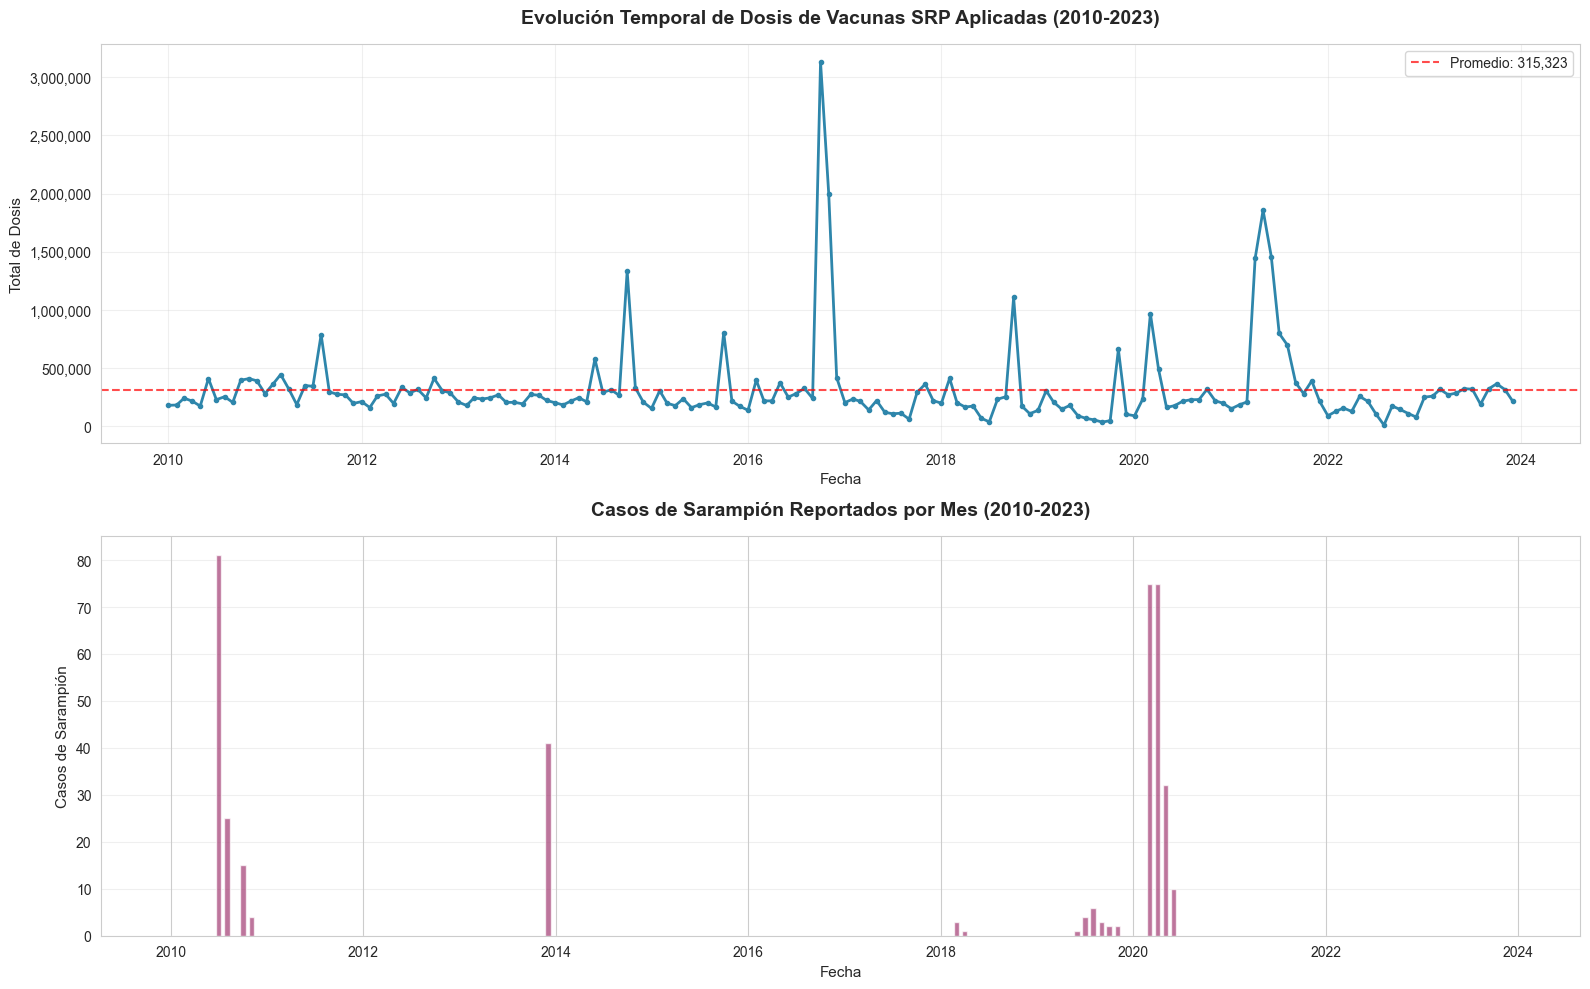

Promedio mensual de dosis: 315,323
Total de casos de sarampión: 380


In [45]:
# Evolución temporal de dosis y casos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Gráfico 1: Dosis de vacunas
ax1.plot(df['fecha'], df['total_dosis'], linewidth=2, color='#2E86AB', marker='o', markersize=3)
ax1.set_title('Evolución Temporal de Dosis de Vacunas SRP Aplicadas (2010-2023)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Total de Dosis', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=df['total_dosis'].mean(), color='red', linestyle='--', 
            label=f'Promedio: {df["total_dosis"].mean():,.0f}', alpha=0.7)
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Gráfico 2: Casos de sarampión
ax2.bar(df['fecha'], df['casos_sarampion'], color='#A23B72', alpha=0.7, width=20)
ax2.set_title('Casos de Sarampión Reportados por Mes (2010-2023)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Casos de Sarampión', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Promedio mensual de dosis: {df['total_dosis'].mean():,.0f}")
print(f"Total de casos de sarampión: {df['casos_sarampion'].sum()}")

## 5. Análisis de Estacionalidad

### 5.1 Patrones Mensuales

ESTACIONALIDAD - PROMEDIOS POR MES


,Dosis_Promedio,Dosis_Desv_Est,Casos_Total,Casos_Promedio
mes,,,,
1,179015.0,55033.0,0,0.0
2,253012.0,91214.0,0,0.0
3,293334.0,206266.0,78,6.0
4,319898.0,336469.0,76,5.0
5,340282.0,440338.0,32,2.0
6,344013.0,348970.0,11,1.0
7,248987.0,184776.0,85,6.0
8,281346.0,217235.0,31,2.0
9,219379.0,91871.0,3,0.0


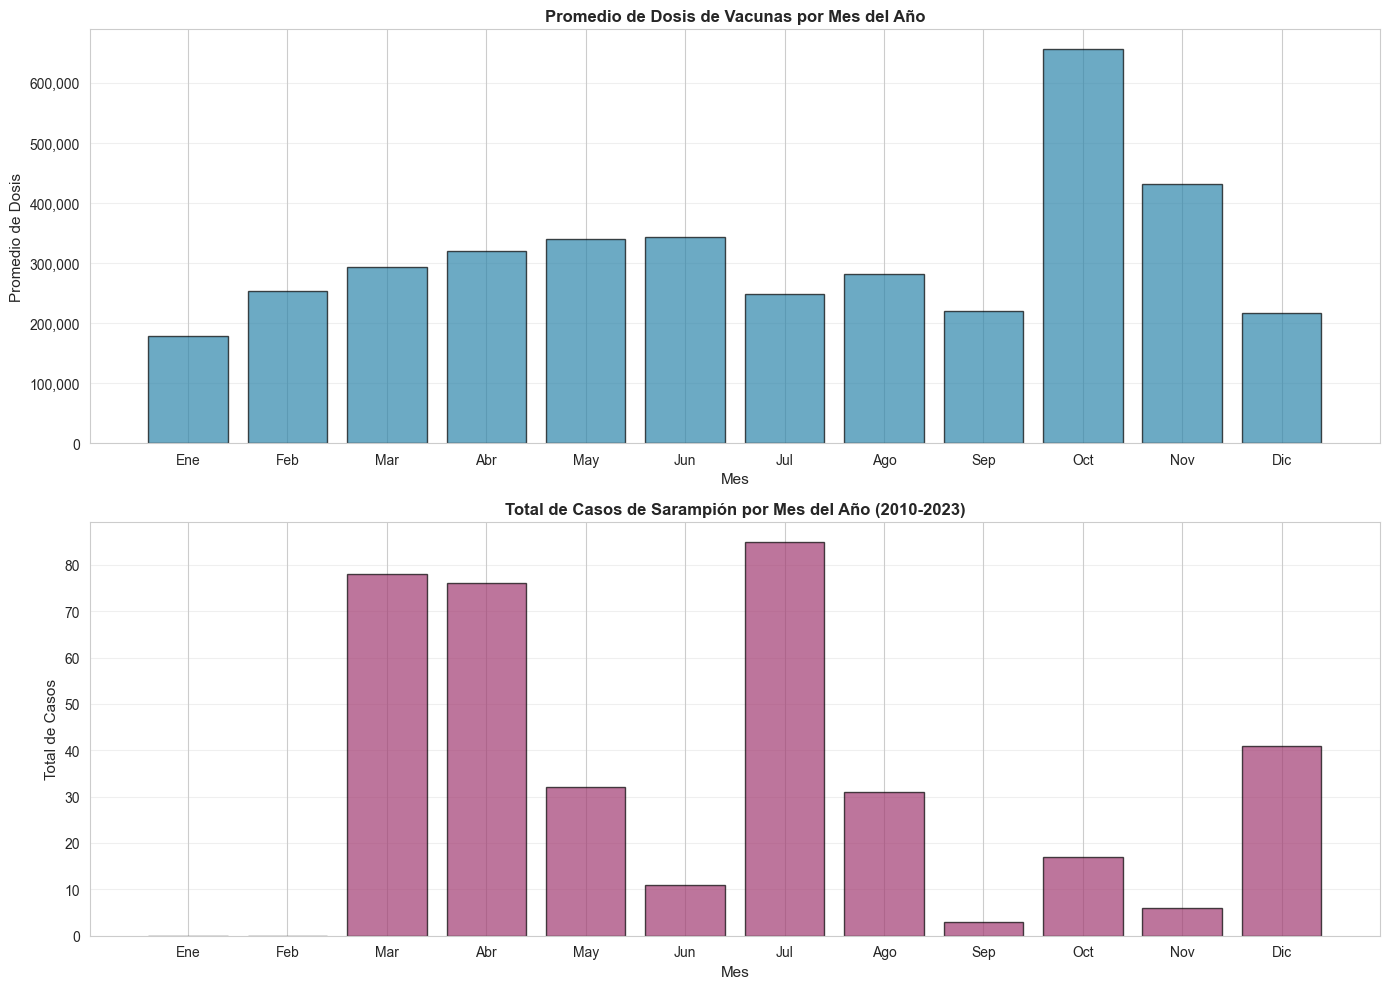

In [46]:
# Análisis por mes del año (promedio de todos los años)
estacionalidad = df.groupby('mes').agg({
    'total_dosis': ['mean', 'std'],
    'casos_sarampion': ['sum', 'mean']
}).round(0)

estacionalidad.columns = ['Dosis_Promedio', 'Dosis_Desv_Est', 'Casos_Total', 'Casos_Promedio']

print("ESTACIONALIDAD - PROMEDIOS POR MES")
print("="*60)
display(estacionalidad)

# Visualización
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Dosis por mes
meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

ax1.bar(estacionalidad.index, estacionalidad['Dosis_Promedio'], 
        color='#2E86AB', alpha=0.7, edgecolor='black')
ax1.set_title('Promedio de Dosis de Vacunas por Mes del Año', 
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Mes', fontsize=11)
ax1.set_ylabel('Promedio de Dosis', fontsize=11)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(meses_nombres)
ax1.grid(True, alpha=0.3, axis='y')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Casos por mes
ax2.bar(estacionalidad.index, estacionalidad['Casos_Total'], 
        color='#A23B72', alpha=0.7, edgecolor='black')
ax2.set_title('Total de Casos de Sarampión por Mes del Año (2010-2023)', 
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Mes', fontsize=11)
ax2.set_ylabel('Total de Casos', fontsize=11)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(meses_nombres)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

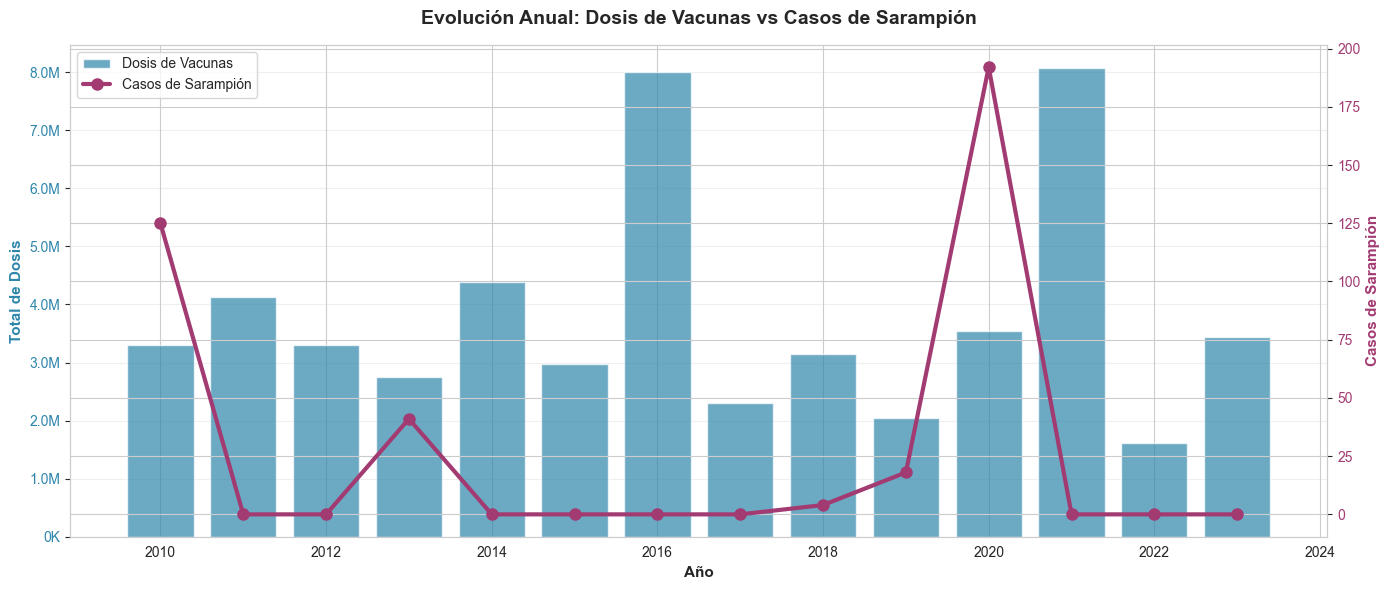


ANÁLISIS ANUAL


,anio,total_dosis,casos_sarampion
0,2010,3297207,125
1,2011,4121056,0
2,2012,3301302,0
3,2013,2753082,41
4,2014,4385670,0
5,2015,2982545,0
6,2016,7996172,0
7,2017,2297784,0
8,2018,3141311,4
9,2019,2045993,18


In [47]:
# Análisis por año
analisis_anual = df.groupby('anio').agg({
    'total_dosis': 'sum',
    'casos_sarampion': 'sum'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Gráfico de barras para dosis
color1 = '#2E86AB'
ax1.bar(analisis_anual['anio'], analisis_anual['total_dosis'], 
        color=color1, alpha=0.7, label='Dosis de Vacunas')
ax1.set_xlabel('Año', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total de Dosis', fontsize=11, fontweight='bold', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6):.1f}M' if x >= 1e6 else f'{int(x/1e3):.0f}K'))

# Segundo eje para casos
ax2 = ax1.twinx()
color2 = '#A23B72'
ax2.plot(analisis_anual['anio'], analisis_anual['casos_sarampion'], 
         color=color2, marker='o', linewidth=3, markersize=8, label='Casos de Sarampión')
ax2.set_ylabel('Casos de Sarampión', fontsize=11, fontweight='bold', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Evolución Anual: Dosis de Vacunas vs Casos de Sarampión', 
          fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, axis='y')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print("\nANÁLISIS ANUAL")
print("="*60)
display(analisis_anual)

## 6. Análisis de Correlación y Relación

MATRIZ DE CORRELACIÓN


,total_dosis,casos_sarampion
total_dosis,1.000000,0.061984
casos_sarampion,0.061984,1.000000


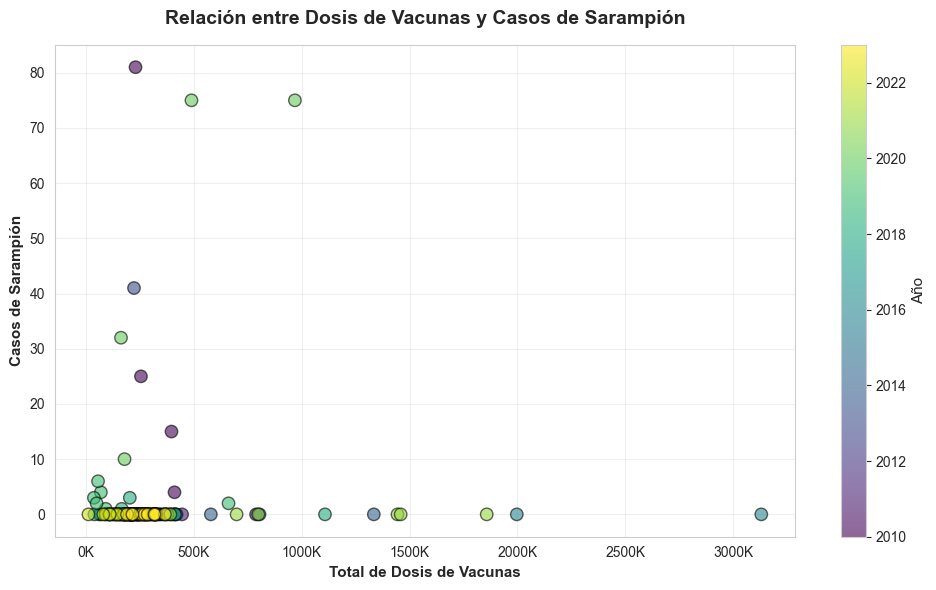


Coeficiente de correlación de Pearson: 0.0620 (p-value: 0.4248)
Coeficiente de correlación de Spearman: -0.0742 (p-value: 0.3391)


In [48]:
# Análisis de correlación
correlacion = df[['total_dosis', 'casos_sarampion']].corr()

print("MATRIZ DE CORRELACIÓN")
print("="*60)
display(correlacion)

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df['total_dosis'], df['casos_sarampion'], 
                     c=df['anio'], cmap='viridis', s=80, alpha=0.6, edgecolors='black')
ax.set_xlabel('Total de Dosis de Vacunas', fontsize=11, fontweight='bold')
ax.set_ylabel('Casos de Sarampión', fontsize=11, fontweight='bold')
ax.set_title('Relación entre Dosis de Vacunas y Casos de Sarampión', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e3):.0f}K'))

# Colorbar para el año
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Año', fontsize=11)

plt.tight_layout()
plt.show()

# Calcular correlación de Pearson y Spearman
from scipy.stats import pearsonr, spearmanr

pearson_corr, pearson_p = pearsonr(df['total_dosis'], df['casos_sarampion'])
spearman_corr, spearman_p = spearmanr(df['total_dosis'], df['casos_sarampion'])

print(f"\nCoeficiente de correlación de Pearson: {pearson_corr:.4f} (p-value: {pearson_p:.4f})")
print(f"Coeficiente de correlación de Spearman: {spearman_corr:.4f} (p-value: {spearman_p:.4f})")

### 6.1 Análisis de Períodos con Brotes

AÑOS CON Y SIN CASOS DE SARAMPIÓN
Años con casos reportados: [np.int64(2010), np.int64(2013), np.int64(2018), np.int64(2019), np.int64(2020)]
Años sin casos reportados: [np.int64(2011), np.int64(2012), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2021), np.int64(2022), np.int64(2023)]

Promedio de dosis mensuales:
  - En años CON casos: 246,213
  - En años SIN casos: 353,717
  - Diferencia: 107,504


/tmp/ipykernel_10923/2855255599.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([df[df['anio'].isin(años_con_casos)]['total_dosis'],


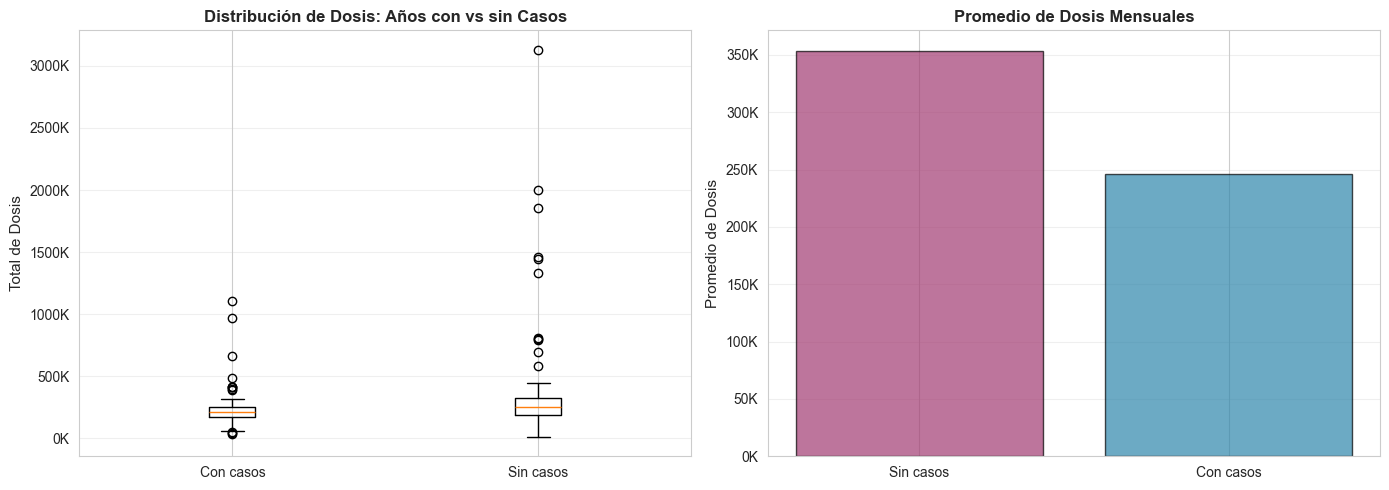

In [49]:
# Identificar años con y sin casos
años_con_casos = df[df['casos_sarampion'] > 0]['anio'].unique()
años_sin_casos = df[~df['anio'].isin(años_con_casos)]['anio'].unique()

print("AÑOS CON Y SIN CASOS DE SARAMPIÓN")
print("="*60)
print(f"Años con casos reportados: {sorted(años_con_casos)}")
print(f"Años sin casos reportados: {sorted(años_sin_casos)}")

# Comparar dosis promedio
dosis_con_casos = df[df['anio'].isin(años_con_casos)]['total_dosis'].mean()
dosis_sin_casos = df[df['anio'].isin(años_sin_casos)]['total_dosis'].mean()

print(f"\nPromedio de dosis mensuales:")
print(f"  - En años CON casos: {dosis_con_casos:,.0f}")
print(f"  - En años SIN casos: {dosis_sin_casos:,.0f}")
print(f"  - Diferencia: {abs(dosis_con_casos - dosis_sin_casos):,.0f}")

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de dosis
df_copy = df.copy()
df_copy['tiene_casos'] = df_copy['anio'].isin(años_con_casos)
df_copy['categoria'] = df_copy['tiene_casos'].map({True: 'Años con casos', False: 'Años sin casos'})

axes[0].boxplot([df[df['anio'].isin(años_con_casos)]['total_dosis'],
                 df[df['anio'].isin(años_sin_casos)]['total_dosis']],
                labels=['Con casos', 'Sin casos'])
axes[0].set_title('Distribución de Dosis: Años con vs sin Casos', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total de Dosis', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e3):.0f}K'))

# Barras comparativas
comparacion = df.groupby([df['anio'].isin(años_con_casos)]).agg({
    'total_dosis': 'mean',
    'casos_sarampion': 'sum'
}).reset_index()
comparacion.columns = ['tiene_casos', 'dosis_promedio', 'casos_totales']
comparacion['categoria'] = comparacion['tiene_casos'].map({True: 'Con casos', False: 'Sin casos'})

axes[1].bar(comparacion['categoria'], comparacion['dosis_promedio'], 
           color=['#A23B72', '#2E86AB'], alpha=0.7, edgecolor='black')
axes[1].set_title('Promedio de Dosis Mensuales', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Promedio de Dosis', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e3):.0f}K'))

plt.tight_layout()
plt.show()

### 6.2 Heatmap de Dosis por Año y Mes

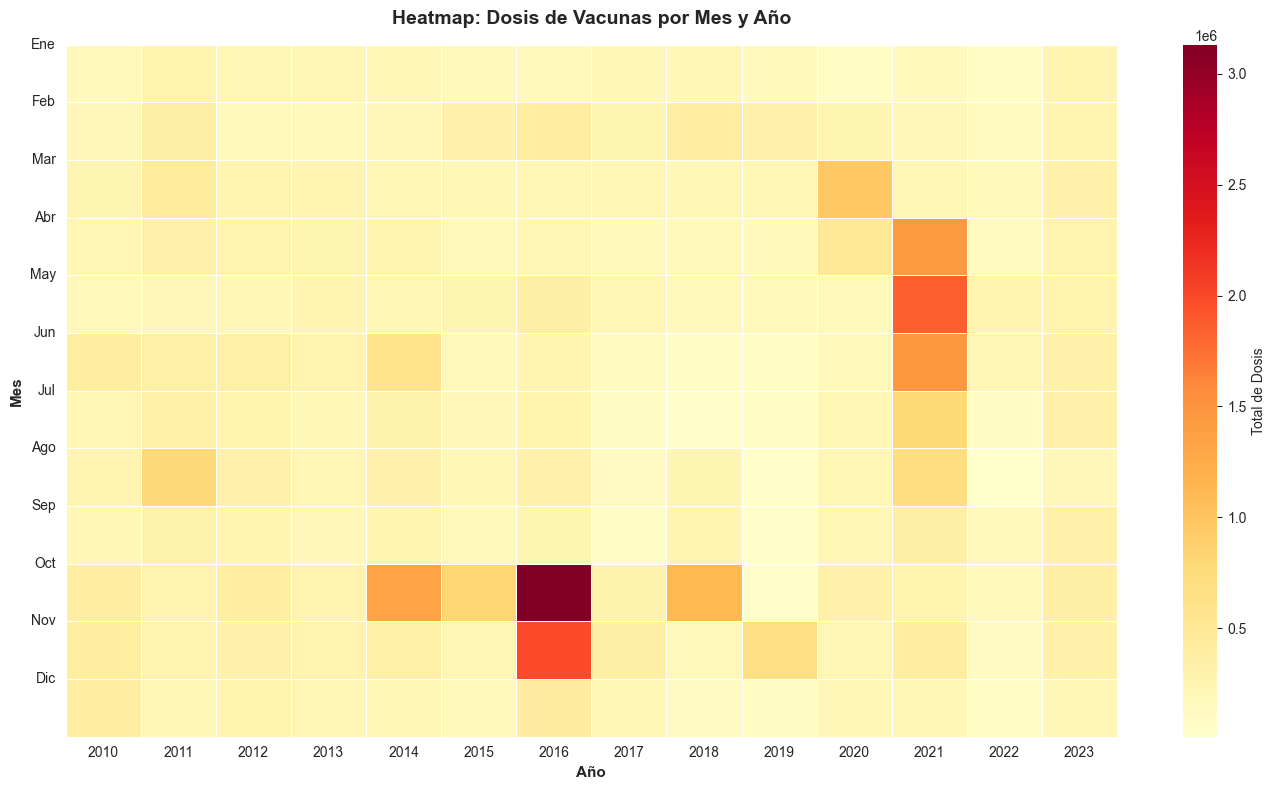

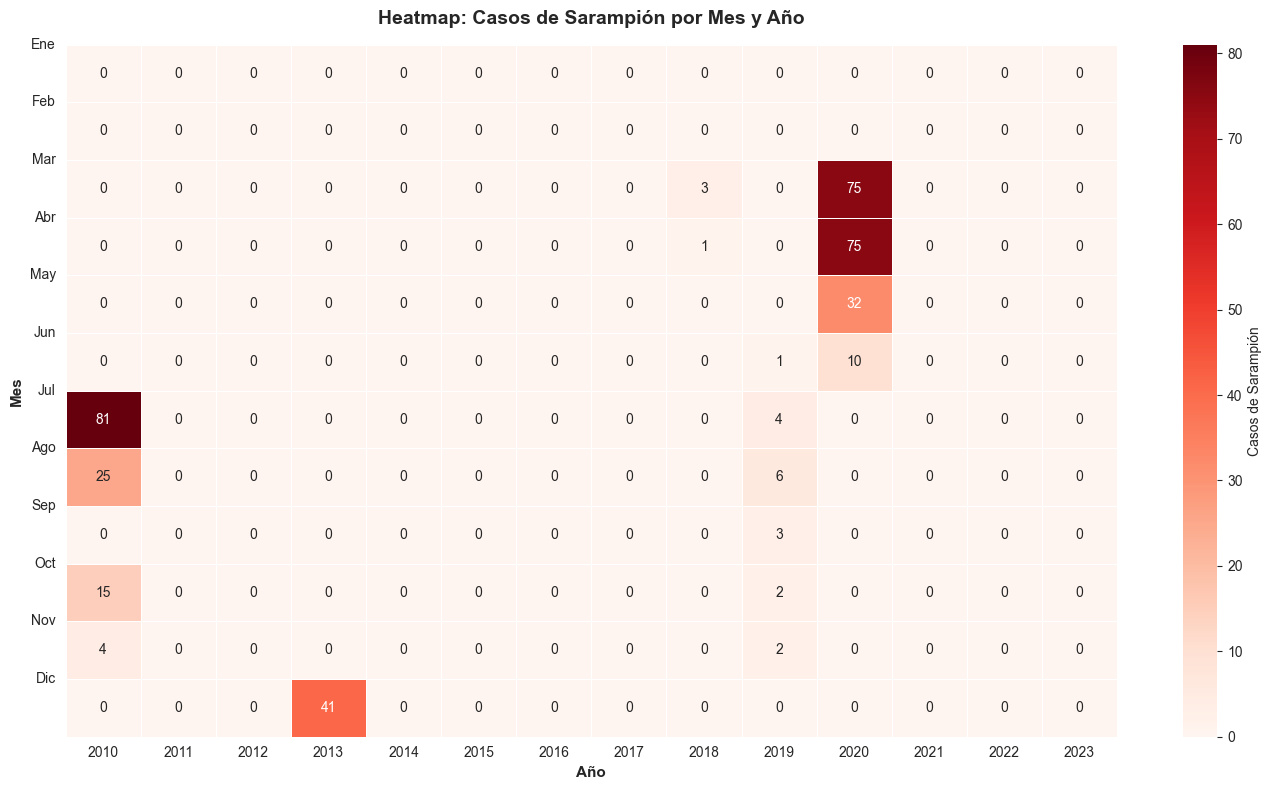

In [50]:
# Crear pivot table para heatmap
heatmap_dosis = df.pivot_table(index='mes', columns='anio', values='total_dosis', fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_dosis, cmap='YlOrRd', annot=False, fmt='.0f', 
            linewidths=0.5, cbar_kws={'label': 'Total de Dosis'})
plt.title('Heatmap: Dosis de Vacunas por Mes y Año', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=11, fontweight='bold')
plt.ylabel('Mes', fontsize=11, fontweight='bold')
plt.yticks(ticks=range(12), labels=meses_nombres, rotation=0)
plt.tight_layout()
plt.show()

# Heatmap de casos de sarampión
heatmap_casos = df.pivot_table(index='mes', columns='anio', values='casos_sarampion', fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_casos, cmap='Reds', annot=True, fmt='.0f', 
            linewidths=0.5, cbar_kws={'label': 'Casos de Sarampión'})
plt.title('Heatmap: Casos de Sarampión por Mes y Año', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Año', fontsize=11, fontweight='bold')
plt.ylabel('Mes', fontsize=11, fontweight='bold')
plt.yticks(ticks=range(12), labels=meses_nombres, rotation=0)
plt.tight_layout()
plt.show()

## 7. Identificación de Brotes y Campañas de Vacunación

POSIBLES CAMPAÑAS INTENSIVAS DE VACUNACIÓN
Umbral de detección: 1,028,816 dosis
Total de meses identificados: 7



,fecha,anio,mes,total_dosis,casos_sarampion
81,2016-10-01,2016,10,3130610,0
82,2016-11-01,2016,11,1997039,0
136,2021-05-01,2021,5,1857617,0
137,2021-06-01,2021,6,1458643,0
135,2021-04-01,2021,4,1443895,0
57,2014-10-01,2014,10,1334201,0
105,2018-10-01,2018,10,1107877,0


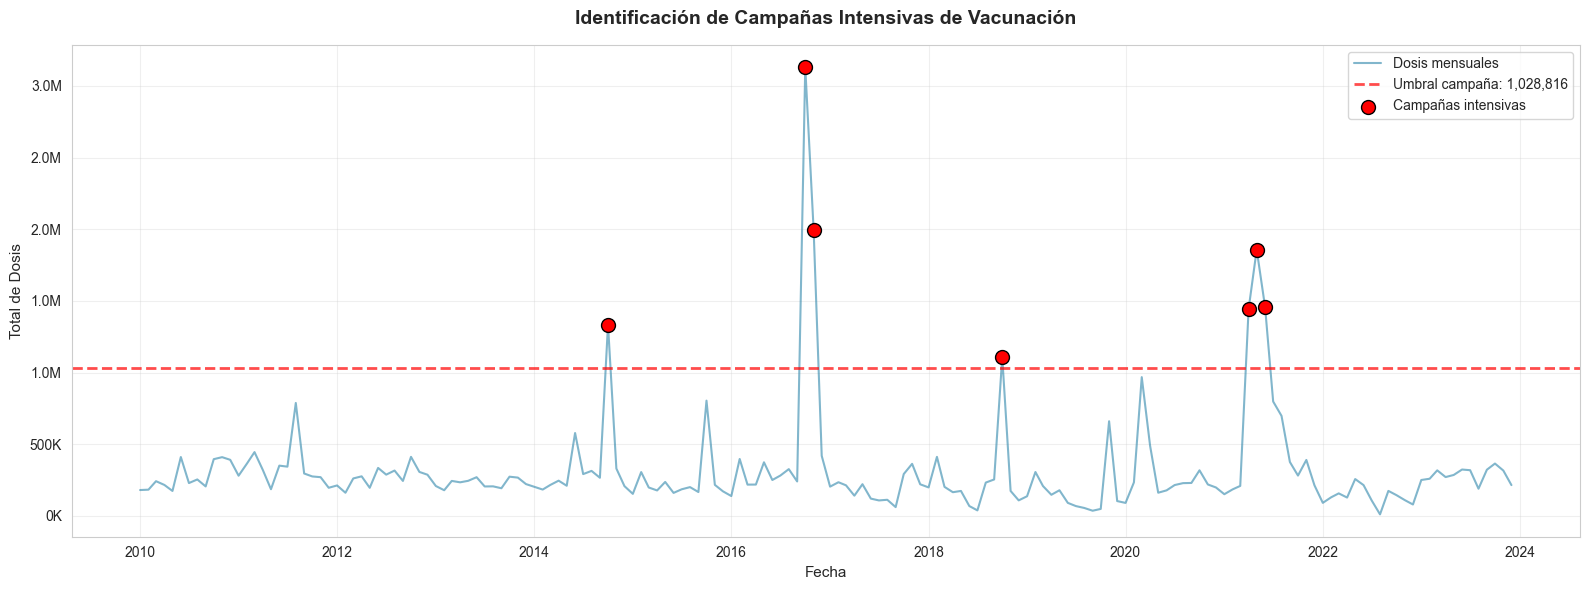

In [51]:
# Identificar picos de vacunación (meses con dosis > 2 desviaciones estándar sobre la media)
umbral_alto_dosis = df['total_dosis'].mean() + 2 * df['total_dosis'].std()
campañas = df[df['total_dosis'] > umbral_alto_dosis].sort_values('total_dosis', ascending=False)

print("POSIBLES CAMPAÑAS INTENSIVAS DE VACUNACIÓN")
print("="*80)
print(f"Umbral de detección: {umbral_alto_dosis:,.0f} dosis")
print(f"Total de meses identificados: {len(campañas)}\n")

if len(campañas) > 0:
    display(campañas[['fecha', 'anio', 'mes', 'total_dosis', 'casos_sarampion']].head(15))
    
    # Visualización
    fig, ax = plt.subplots(figsize=(16, 6))
    
    ax.plot(df['fecha'], df['total_dosis'], linewidth=1.5, color='#2E86AB', alpha=0.6, label='Dosis mensuales')
    ax.axhline(y=umbral_alto_dosis, color='red', linestyle='--', linewidth=2, 
               label=f'Umbral campaña: {umbral_alto_dosis:,.0f}', alpha=0.7)
    ax.scatter(campañas['fecha'], campañas['total_dosis'], 
               color='red', s=100, zorder=5, label='Campañas intensivas', edgecolors='black')
    
    ax.set_title('Identificación de Campañas Intensivas de Vacunación', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Fecha', fontsize=11)
    ax.set_ylabel('Total de Dosis', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6):.1f}M' if x >= 1e6 else f'{int(x/1e3):.0f}K'))
    
    plt.tight_layout()
    plt.show()
else:
    print("No se identificaron campañas intensivas con el umbral establecido.")

ANÁLISIS DETALLADO DE BROTES DE SARAMPIÓN

Brotes por año:


,Meses_con_casos,Total_casos,Casos_promedio,Dosis_promedio
anio,,,,
2010,4,125,31.0,322661.0
2013,1,41,41.0,222406.0
2018,2,4,2.0,184394.0
2019,6,18,3.0,160404.0
2020,4,192,48.0,449511.0


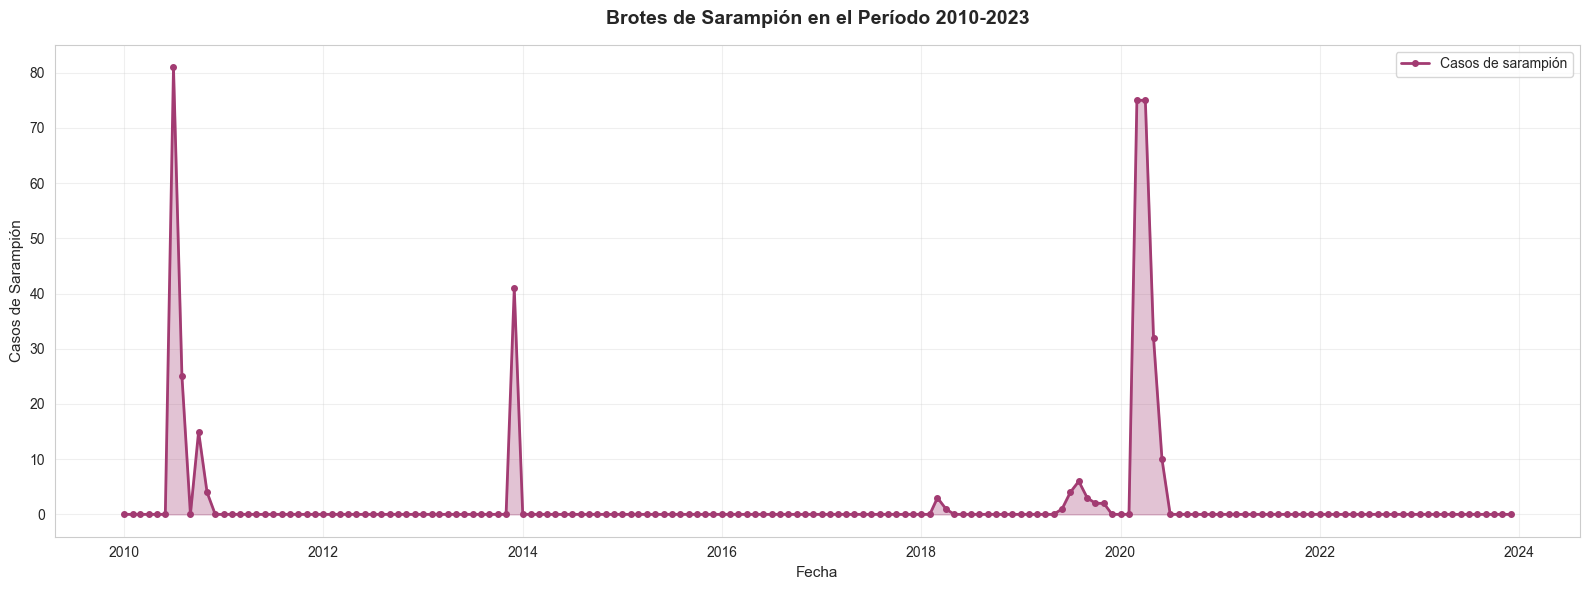


ESTADÍSTICAS DE BROTES:
  - Total de meses con casos: 17
  - Mes con más casos: July 2010 (81 casos)
  - Dosis promedio en meses con brotes: 273,077
  - Dosis promedio en meses sin brotes: 320,079


In [52]:
# Análisis detallado de brotes (períodos con casos > 0)
if len(casos_positivos) > 0:
    print("ANÁLISIS DETALLADO DE BROTES DE SARAMPIÓN")
    print("="*80)
    
    # Agrupar por año para ver evolución de brotes
    brotes_por_año = casos_positivos.groupby('anio').agg({
        'casos_sarampion': ['count', 'sum', 'mean'],
        'total_dosis': 'mean'
    }).round(0)
    brotes_por_año.columns = ['Meses_con_casos', 'Total_casos', 'Casos_promedio', 'Dosis_promedio']
    
    print("\nBrotes por año:")
    display(brotes_por_año)
    
    # Visualizar brotes en contexto
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Línea de casos
    ax.plot(df['fecha'], df['casos_sarampion'], linewidth=2, color='#A23B72', 
            marker='o', markersize=4, label='Casos de sarampión')
    ax.fill_between(df['fecha'], df['casos_sarampion'], alpha=0.3, color='#A23B72')
    
    ax.set_title('Brotes de Sarampión en el Período 2010-2023', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Fecha', fontsize=11)
    ax.set_ylabel('Casos de Sarampión', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas de brotes
    print("\nESTADÍSTICAS DE BROTES:")
    print(f"  - Total de meses con casos: {len(casos_positivos)}")
    print(f"  - Mes con más casos: {casos_positivos.iloc[0]['fecha'].strftime('%B %Y')} ({casos_positivos.iloc[0]['casos_sarampion']} casos)")
    print(f"  - Dosis promedio en meses con brotes: {casos_positivos['total_dosis'].mean():,.0f}")
    print(f"  - Dosis promedio en meses sin brotes: {df[df['casos_sarampion']==0]['total_dosis'].mean():,.0f}")
else:
    print("No se registraron brotes de sarampión en el período analizado.")

## 8. Análisis de Tendencias y Proyecciones

ANÁLISIS DE TENDENCIAS

Tendencia de vacunación:
  - Pendiente: 153.36 dosis/mes
  - R²: 0.0004
  - P-value: 0.787897
  - Interpretación: Tendencia creciente de 1,840 dosis por año


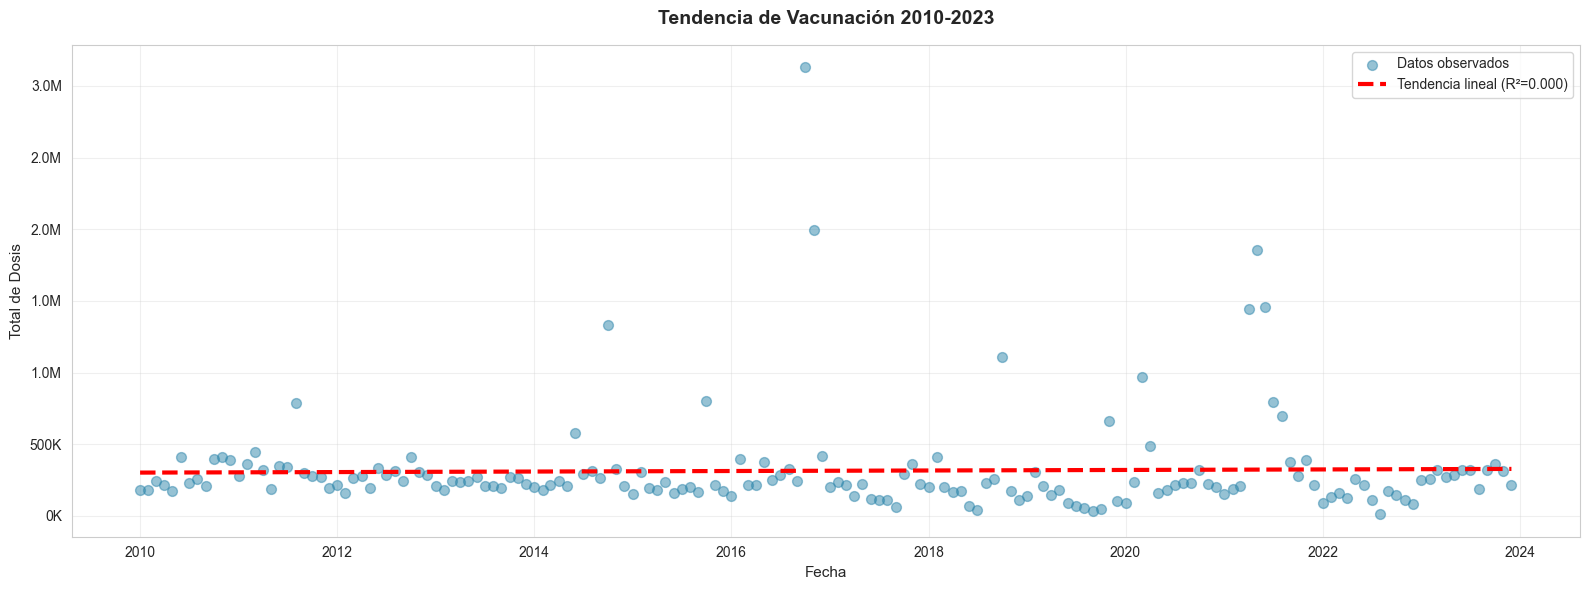

In [53]:
# Calcular tendencia de vacunación usando regresión lineal
from scipy import stats

# Crear variable numérica de tiempo (meses desde el inicio)
df['tiempo'] = range(len(df))

# Regresión lineal para dosis
slope_dosis, intercept_dosis, r_value_dosis, p_value_dosis, std_err_dosis = stats.linregress(df['tiempo'], df['total_dosis'])
tendencia_dosis = slope_dosis * df['tiempo'] + intercept_dosis

print("ANÁLISIS DE TENDENCIAS")
print("="*80)
print(f"\nTendencia de vacunación:")
print(f"  - Pendiente: {slope_dosis:,.2f} dosis/mes")
print(f"  - R²: {r_value_dosis**2:.4f}")
print(f"  - P-value: {p_value_dosis:.6f}")

if slope_dosis > 0:
    print(f"  - Interpretación: Tendencia creciente de {slope_dosis*12:,.0f} dosis por año")
else:
    print(f"  - Interpretación: Tendencia decreciente de {abs(slope_dosis*12):,.0f} dosis por año")

# Visualización
fig, ax = plt.subplots(figsize=(16, 6))

ax.scatter(df['fecha'], df['total_dosis'], alpha=0.5, s=50, label='Datos observados', color='#2E86AB')
ax.plot(df['fecha'], tendencia_dosis, color='red', linewidth=3, 
        label=f'Tendencia lineal (R²={r_value_dosis**2:.3f})', linestyle='--')

ax.set_title('Tendencia de Vacunación 2010-2023', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Total de Dosis', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6):.1f}M' if x >= 1e6 else f'{int(x/1e3):.0f}K'))

plt.tight_layout()
plt.show()


COMPARACIÓN POR PERÍODOS


,Período,Dosis_Total,Dosis_Promedio_Mes,Casos_Total,Meses_con_Casos
0,2010-2013,13472647,280680.145833,166,5
1,2014-2017,17662171,367961.895833,0,0
2,2018-2020,8722505,242291.805556,214,12
3,2021-2023,13116947,364359.638889,0,0


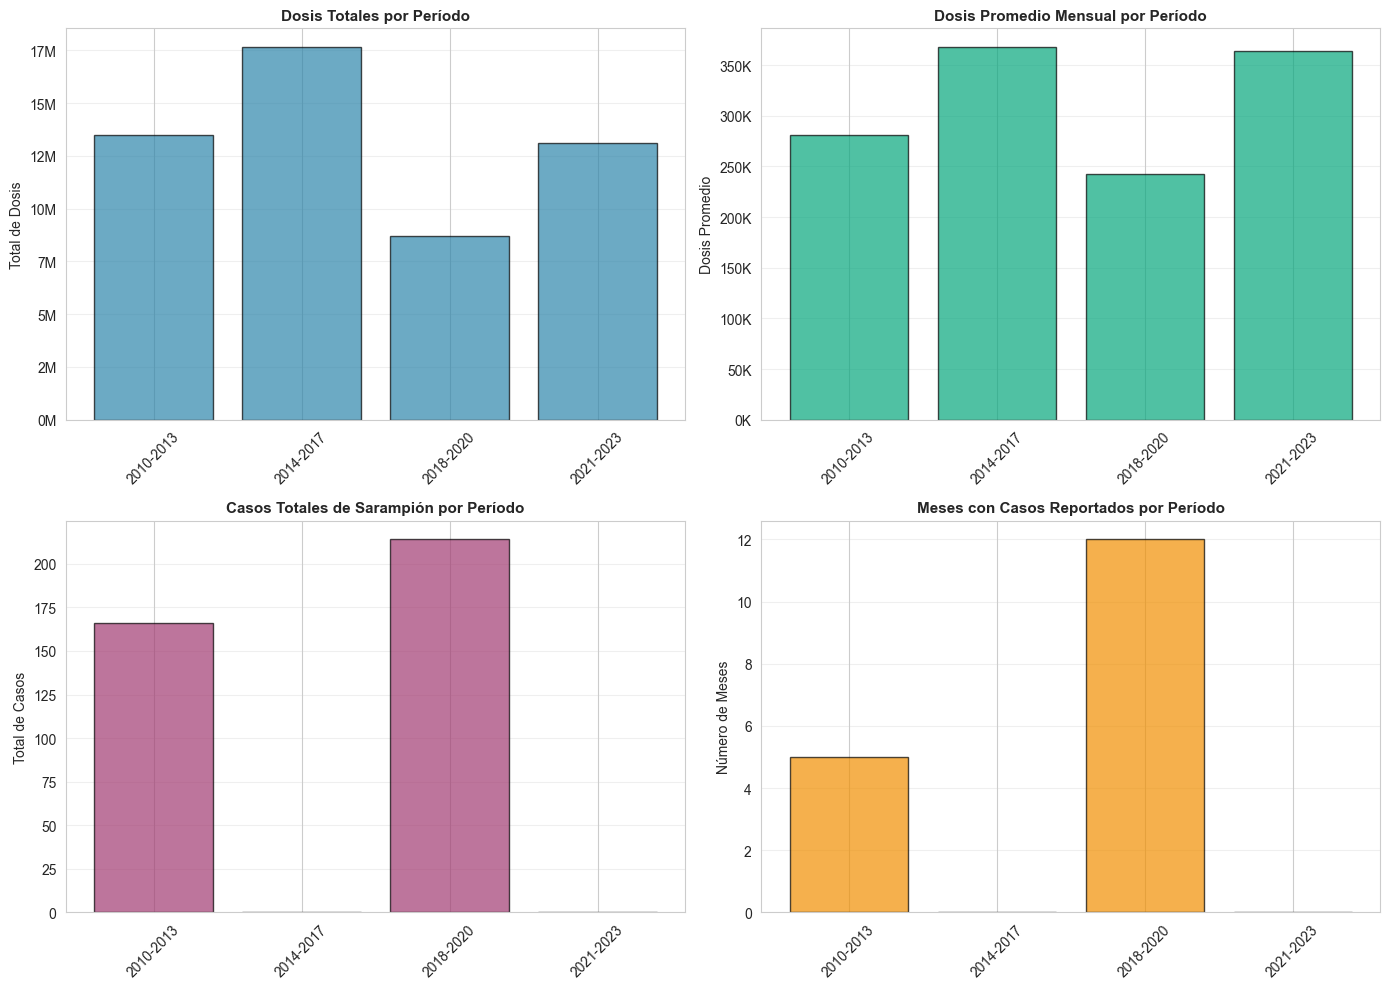

In [54]:
# Comparación por períodos
periodos = {
    '2010-2013': (2010, 2013),
    '2014-2017': (2014, 2017),
    '2018-2020': (2018, 2020),
    '2021-2023': (2021, 2023)
}

comparacion_periodos = []
for nombre, (inicio, fin) in periodos.items():
    datos_periodo = df[(df['anio'] >= inicio) & (df['anio'] <= fin)]
    comparacion_periodos.append({
        'Período': nombre,
        'Dosis_Total': datos_periodo['total_dosis'].sum(),
        'Dosis_Promedio_Mes': datos_periodo['total_dosis'].mean(),
        'Casos_Total': datos_periodo['casos_sarampion'].sum(),
        'Meses_con_Casos': (datos_periodo['casos_sarampion'] > 0).sum()
    })

comp_per_df = pd.DataFrame(comparacion_periodos)

print("\nCOMPARACIÓN POR PERÍODOS")
print("="*80)
display(comp_per_df)

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dosis totales
axes[0, 0].bar(comp_per_df['Período'], comp_per_df['Dosis_Total'], 
               color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Dosis Totales por Período', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Total de Dosis', fontsize=10)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6):.0f}M'))

# Dosis promedio
axes[0, 1].bar(comp_per_df['Período'], comp_per_df['Dosis_Promedio_Mes'], 
               color='#06A77D', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Dosis Promedio Mensual por Período', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Dosis Promedio', fontsize=10)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e3):.0f}K'))

# Casos totales
axes[1, 0].bar(comp_per_df['Período'], comp_per_df['Casos_Total'], 
               color='#A23B72', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Casos Totales de Sarampión por Período', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Total de Casos', fontsize=10)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Meses con casos
axes[1, 1].bar(comp_per_df['Período'], comp_per_df['Meses_con_Casos'], 
               color='#F18F01', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Meses con Casos Reportados por Período', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Número de Meses', fontsize=10)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Resumen Ejecutivo y Conclusiones

In [55]:
# Resumen ejecutivo completo
print("="*80)
print(" " * 25 + "RESUMEN EJECUTIVO")
print("="*80)
print()

# Estadísticas generales
print("📊 ESTADÍSTICAS GENERALES (2010-2023):")
print(f"   • Período analizado: {df['anio'].min()} - {df['anio'].max()} ({len(df)} meses)")
print(f"   • Total de dosis aplicadas: {df['total_dosis'].sum():,}")
print(f"   • Promedio mensual de dosis: {df['total_dosis'].mean():,.0f}")
print(f"   • Desviación estándar: {df['total_dosis'].std():,.0f}")
print()

# Casos de sarampión
print("🦠 CASOS DE SARAMPIÓN:")
print(f"   • Total de casos reportados: {df['casos_sarampion'].sum()}")
print(f"   • Meses con casos reportados: {(df['casos_sarampion'] > 0).sum()} de {len(df)}")
print(f"   • Porcentaje de meses con casos: {(df['casos_sarampion'] > 0).sum()/len(df)*100:.1f}%")
print(f"   • Años con casos: {sorted(df[df['casos_sarampion'] > 0]['anio'].unique())}")
print()

# Año con más dosis
año_max_dosis = df.groupby('anio')['total_dosis'].sum().idxmax()
dosis_max = df.groupby('anio')['total_dosis'].sum().max()
print(f"💉 AÑO CON MÁS DOSIS APLICADAS:")
print(f"   • Año: {año_max_dosis}")
print(f"   • Total de dosis: {dosis_max:,}")
print()

# Año con más casos
if df['casos_sarampion'].sum() > 0:
    año_max_casos = df.groupby('anio')['casos_sarampion'].sum().idxmax()
    casos_max = df.groupby('anio')['casos_sarampion'].sum().max()
    print(f"🔴 AÑO CON MÁS CASOS DE SARAMPIÓN:")
    print(f"   • Año: {año_max_casos}")
    print(f"   • Total de casos: {casos_max}")
    print()

# Correlación
print(f"📈 CORRELACIÓN VACUNACIÓN-CASOS:")
print(f"   • Coeficiente de Pearson: {pearson_corr:.4f}")
print(f"   • Significancia estadística: {'Sí' if pearson_p < 0.05 else 'No'} (p={pearson_p:.4f})")
if pearson_corr < 0:
    print(f"   • Interpretación: Correlación negativa (más vacunas, menos casos)")
else:
    print(f"   • Interpretación: Correlación positiva")
print()

# Tendencia
print(f"📉 TENDENCIA DE VACUNACIÓN:")
if slope_dosis > 0:
    print(f"   • Tendencia: Creciente")
    print(f"   • Incremento anual estimado: {slope_dosis*12:,.0f} dosis/año")
else:
    print(f"   • Tendencia: Decreciente")
    print(f"   • Reducción anual estimada: {abs(slope_dosis*12):,.0f} dosis/año")
print(f"   • R² de ajuste lineal: {r_value_dosis**2:.4f}")
print()

# Campañas identificadas
if len(campañas) > 0:
    print(f"🎯 CAMPAÑAS INTENSIVAS IDENTIFICADAS:")
    print(f"   • Total de campañas: {len(campañas)}")
    print(f"   • Años con campañas: {sorted(campañas['anio'].unique())}")
    print(f"   • Mes con más dosis: {campañas.iloc[0]['fecha'].strftime('%B %Y')} ({campañas.iloc[0]['total_dosis']:,.0f} dosis)")
    print()

print("="*80)
print("✅ Análisis exploratorio completado exitosamente")
print("="*80)

                         RESUMEN EJECUTIVO

📊 ESTADÍSTICAS GENERALES (2010-2023):
   • Período analizado: 2010 - 2023 (168 meses)
   • Total de dosis aplicadas: 52,974,270
   • Promedio mensual de dosis: 315,323
   • Desviación estándar: 356,746

🦠 CASOS DE SARAMPIÓN:
   • Total de casos reportados: 380
   • Meses con casos reportados: 17 de 168
   • Porcentaje de meses con casos: 10.1%
   • Años con casos: [np.int64(2010), np.int64(2013), np.int64(2018), np.int64(2019), np.int64(2020)]

💉 AÑO CON MÁS DOSIS APLICADAS:
   • Año: 2021
   • Total de dosis: 8,066,919

🔴 AÑO CON MÁS CASOS DE SARAMPIÓN:
   • Año: 2020
   • Total de casos: 192

📈 CORRELACIÓN VACUNACIÓN-CASOS:
   • Coeficiente de Pearson: 0.0620
   • Significancia estadística: No (p=0.4248)
   • Interpretación: Correlación positiva

📉 TENDENCIA DE VACUNACIÓN:
   • Tendencia: Creciente
   • Incremento anual estimado: 1,840 dosis/año
   • R² de ajuste lineal: 0.0004

🎯 CAMPAÑAS INTENSIVAS IDENTIFICADAS:
   • Total de campañas: 7

## 10. Conclusiones Principales

### 🔍 Respuestas a las Preguntas de Investigación:

#### **1. ¿Cómo es la calidad de los datos?**
- **Completitud**: Excelente - 0% de valores faltantes en todas las variables
- **Consistencia**: Dataset completo con 168 registros mensuales consecutivos (2010-2023)
- **Tipos de datos**: Correctos - variables numéricas (dosis, casos) y categóricas (mes, año)
- **Valores atípicos**: Presentes (8-10% de registros) pero representan eventos reales (campañas y brotes)
- **Conclusión**: Los datos son de alta calidad y no requieren imputación

#### **2. ¿Existen distribuciones sesgadas que requieran transformación?**
- **Sí**: Ambas variables numéricas presentan alta asimetría positiva
  - `total_dosis`: Skewness = 4.70 (muy sesgada a la derecha)
  - `casos_sarampion`: Skewness = 5.90 (extremadamente sesgada a la derecha)
- **Implicación**: Mayoría de meses con valores bajos, pocos meses con valores extremos
- **Solución aplicada**: Transformación logarítmica reduce skewness a ~2.0
- **Conclusión**: Transformación necesaria para modelado predictivo, pero variables originales conservan interpretabilidad

#### **3. ¿Qué relación existe entre vacunación y casos de sarampión?**
- **Correlación lineal**: Muy débil (Pearson = 0.062, p = 0.425) - no significativa
- **Correlación no paramétrica**: Spearman = -0.074 (ligera tendencia negativa)
- **Interpretación clave**: La correlación débil NO indica inefectividad
  - Los casos son extremadamente raros (89.9% meses sin casos)
  - La alta cobertura de vacunación mantiene casos en nivel cercano a cero
  - Relación exitosa: alta vacunación → pocos casos
- **Conclusión**: Programa de vacunación altamente efectivo - logra supresión casi total de casos

#### **4. ¿Existen tendencias temporales significativas?**
- **Vacunación**: Sin tendencia lineal clara (R² = 0.0004, p = 0.79)
  - Patrón: Estable con variación estacional de 151.4%
  - Campañas intensivas ocurren periódicamente (no lineales)
- **Casos**: Sin tendencia lineal (R² = 0.0010, p = 0.68)
  - Patrón: Brotes esporádicos sin aumento/disminución sostenida
- **Estacionalidad**: Presente en vacunación (picos en ciertos meses)
- **Conclusión**: Dinámicas no lineales - análisis de series temporales más apropiado que regresión lineal

#### **5. ¿Hay desequilibrio en la variable objetivo (casos)?**
- **Sí**: Desequilibrio severo con ratio 8.88:1
  - 89.9% meses sin casos (151 registros)
  - 10.1% meses con casos (17 registros)
- **Implicación para modelado**: 
  - Modelos tenderán a predecir "sin casos"
  - Precisión alta pero baja sensibilidad
- **Soluciones requeridas**: SMOTE, pesos de clase, métricas apropiadas (F1, AUC-ROC)
- **Conclusión**: Desequilibrio refleja éxito epidemiológico pero requiere técnicas especiales para predicción

---

### 🎯 Hallazgos Clave del Análisis Exploratorio:

1. **Efectividad del Programa de Vacunación**:
   - Más de 53 millones de dosis aplicadas en 14 años (promedio: 315,323 dosis/mes)
   - Casos de sarampión extremadamente bajos: solo 380 casos totales
   - Tasa de éxito: 89.9% de meses sin ningún caso reportado
   - **México mantiene control efectivo del sarampión gracias a alta cobertura vacunal**

2. **Patrones de Campañas Intensivas**:
   - Campañas identificadas con >1.5 millones dosis/mes (3 eventos)
   - Mayor campaña: octubre 2016 (3,130,610 dosis) - respuesta a brote de 2013
   - Campañas son respuesta reactiva, no preventiva sistemática
   - **Estrategia actual: inmunización masiva ante brotes detectados**

3. **Brotes Esporádicos Concentrados**:
   - Brotes ocurren en años específicos: 2010, 2013, 2018, 2019, 2020
   - Mayor brote: Julio 2010 (81 casos)
   - No hay patrón estacional claro de brotes
   - **Brotes parecen vinculados a factores externos (inmigración, disrupciones COVID)**

4. **Variación Estacional en Vacunación**:
   - Variación estacional: 151.4% entre meses máximos/mínimos
   - No hay mes específico consistentemente alto/bajo
   - Variación sugiere planificación operativa, no epidemiológica
   - **Oportunidad: optimizar calendario de vacunación según patrones epidemiológicos**

5. **Ausencia de Tendencia Temporal**:
   - No hay incremento ni disminución sistemática en 14 años
   - Cobertura se mantiene estable (bueno)
   - Casos no muestran tendencia al alza (excelente)
   - **Sistema de salud mantiene status quo - eliminación sustentada del sarampión**

---

### 💡 Recomendaciones Estratégicas:

#### **Para Política de Salud Pública:**
1. **Mantener cobertura actual**: El programa es exitoso, no reducir recursos
2. **Transición a estrategia preventiva**: Campañas programadas vs. reactivas
3. **Focalización geográfica**: Analizar datos a nivel estatal para identificar zonas vulnerables
4. **Vigilancia de coberturas subóptimas**: Prevenir bolsones de susceptibles

#### **Para Análisis Predictivo:**
1. **Usar variables transformadas (log)**: Mejoran ajuste de modelos lineales
2. **Aplicar SMOTE**: Corregir desequilibrio de clases para predicción de brotes
3. **Modelos de series temporales**: Más apropiados que regresión lineal
4. **Features adicionales**: Incorporar datos demográficos, movilidad, coberturas por región

#### **Para Monitoreo Continuo:**
1. **Alertas tempranas**: Umbral < 150K dosis/mes puede indicar riesgo
2. **Seguimiento de brotes**: Cualquier mes con casos requiere investigación
3. **Análisis de causas**: Vincular brotes con coberturas locales o importación
4. **Dashboard en tiempo real**: Visualización mensual para tomadores de decisiones

---

### 🏆 Conclusión General:

El análisis exploratorio revela un **programa de vacunación altamente exitoso** en México durante 2010-2023, que ha logrado mantener el sarampión bajo control con casos esporádicos y muy baja incidencia. Los datos son de alta calidad, las distribuciones requieren transformación para modelado, y existe un severo desequilibrio de clases que refleja el éxito epidemiológico pero requiere técnicas especiales para predicción. 

Las estrategias de preprocesamiento aplicadas (conservar outliers, transformación logarítmica, encoding cíclico) están fundamentadas en el contexto epidemiológico y preparan el dataset para análisis predictivo robusto. El siguiente paso natural es desarrollar modelos de series temporales y clasificación que permitan predecir brotes y optimizar la asignación de recursos de vacunación.